# 1. Configuración Weights & Biases - Librerías

Instalamos la librería Weights & Biases (W&B), utilizada para el seguimiento y registro de experimentos durante el entrenamiento del modelo, y nos autenticamos con la clave:

In [ ]:
!pip install wandb
import wandb
wandb.login(key="b810dd5ad8d499a2e00ba76a49f368dfeb7019df") # clave de Lucía

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: lpizirestaine (petra_leoni-ditella) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

Instalamos más librerías necesarias:

In [ ]:
# Librerías principales de PyTorch y Torchaudio
!pip -q install --upgrade torch torchaudio --index-url https://download.pytorch.org/whl/cu121

# Módulos de Python y PyTorch
import torch, torchaudio
print(torch.__version__, torchaudio.__version__)

import random
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import RMSprop
from torch.optim.lr_scheduler import ExponentialLR, ReduceLROnPlateau

# Módulos específicos de procesamiento de audio
import torchaudio
from torchaudio import transforms as T

# Librerías para análisis y visualización de datos
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import seaborn as sns

# Utilidades del sistema de archivos
import shutil, os

# Librerías de análisis de datos y métricas de desempeño
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix

2.8.0+cu126 2.8.0+cu126


# 2. Parámetros

Configuramos parámetros globales (provistos por la cátedra):

In [ ]:
# Semilla
SEED = 42

# Carpeta donde se guardará el dataset
DATA_ROOT = Path('/content/data/speech_commands')
DATA_ROOT.mkdir(parents=True, exist_ok=True)

# Clases seleccionadas
CLASSES = ['yes','no','up','down','left','right','on','off','stop','go']

# Parámetros de procesamiento de audio
NATIVE_SR = 16000   # Frecuencia de muestreo de las señales
N_FFT = 256         # Tamaño de ventana FFT
HOP_LENGTH = 160    # Desplazamiento entre ventanas
N_MELS = 32         # Número de bandas Mel para espectrogramas

# Hiperparámetros de entrenamiento
BATCH_SIZE = 128
EPOCHS = 100
LR = 1e-3

# Configuración de dispositivo
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# Fijamos semillas
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
if DEVICE == 'cuda': torch.cuda.manual_seed_all(SEED)

# Dispositivo seleccionado y ruta
print("Device:", DEVICE)
print("Datos en:", DATA_ROOT.resolve())

Device: cpu
Datos en: /content/data/speech_commands


# 3. Descarga & verificación del dataset

In [ ]:
def _lists_exist(root: Path) -> bool:
    """
    Verifica que existan los archivos de listas oficiales (train/val/test)
    proporcionados por el dataset Speech Commands
    """
    base = root / "SpeechCommands" / "speech_commands_v0.02"
    return (base / "validation_list.txt").exists() and (base / "testing_list.txt").exists()

def _bootstrap_download(root: Path):
    """
    Realiza la descarga completa del dataset Speech Commands y verifica
    que se hayan generado correctamente las listas oficiales
    """
    # Eliminar carpetas previas con contenido incompleto
    shutil.rmtree(root / "SpeechCommands", ignore_errors=True)

    # Descargar dataset completo
    _ = torchaudio.datasets.SPEECHCOMMANDS(root=str(root), download=True, subset=None)

    # Verificar que las listas existen
    if not _lists_exist(root):
        raise RuntimeError("No se pudieron crear las listas oficiales tras la descarga.")

# 4. Clase para el dataset

In [ ]:
class MiniSpeechCommandsRaw(Dataset):
    """
    Implementa una versión reducida y controlada del dataset Speech Commands
    - Descarga automática y manejo de errores en caso de dataset incompleto
    - Selección del subconjunto correspondiente (training / validation / testing)
    - Filtrado de audios pertenecientes únicamente a las clases de interés
    - Devuelve el audio crudo (waveform), su frecuencia de muestreo y el label codificado
    """
    def __init__(self, root, classes, subset='training'):
        # Aseguraramos que la carpeta existe
        root = Path(root)
        root.mkdir(parents=True, exist_ok=True)

        try:
            # Intento normal: si ya está en /content, no vuelve a descargar
            base = torchaudio.datasets.SPEECHCOMMANDS(
                root=str(root), download=True, subset=subset
            )
            # Algunas veces torchaudio no tira excepción, pero las faltan las listas de splits
            if not _lists_exist(root):
                raise FileNotFoundError("List files missing after download.")
        except FileNotFoundError:
            # Auto-reparación: descarga completa y reintento sin download
            _bootstrap_download(root)
            base = torchaudio.datasets.SPEECHCOMMANDS(
                root=str(root), download=False, subset=subset
            )

        # Mapeo label -> índice entero
        self.classes = list(classes)
        c2i = {c: i for i, c in enumerate(self.classes)}

        # Filtrado de muestras pertenecientes solo a las clases seleccionadas
        self.items = []
        for i in tqdm(range(len(base)), desc=f"Cargando/filtrando '{subset}'", unit="audio"):
            wav, sr, label, *_ = base[i]
            if label in c2i:
                # Tupla con la señal cruda, la frecuencia y el id de clase
                self.items.append((wav, sr, c2i[label]))

        if not self.items:
            raise RuntimeError(f"Sin ejemplos para {self.classes} en subset={subset}.")

    # Devuelve la cantidad total de ejemplos del subconjunto
    def __len__(self): return len(self.items)

    # Devuelve el ejemplo solicitado por índice
    def __getitem__(self, idx): return self.items[idx]

Cargamos los subconjuntos de datos:

In [ ]:
# 3 instancias del dataset: entrenamiento, validación y test
train_ds = MiniSpeechCommandsRaw(DATA_ROOT, CLASSES, subset='training')
val_ds   = MiniSpeechCommandsRaw(DATA_ROOT, CLASSES, subset='validation')
test_ds  = MiniSpeechCommandsRaw(DATA_ROOT, CLASSES, subset='testing')

# Tamaño de cada split
print(f"Tamaños -> train: {len(train_ds)} | val: {len(val_ds)} | test: {len(test_ds)}")

100%|██████████| 2.26G/2.26G [01:20<00:00, 30.3MB/s]
Cargando/filtrando 'training':   0%|          | 0/84843 [00:00<?, ?audio/s]/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/ffmpeg.py:88: UserWarning: torio.io._streaming_media_decoder.StreamingMediaDecoder has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video ar

Tamaños -> train: 30769 | val: 3703 | test: 4074


Creamos DataLoaders:

In [ ]:
def collate_wave_flat(batch):
    """
    Función de 'collate' que permite agrupar audios de distinta duración
    en un mismo batch mediante padding, y luego aplanar las señales
    """
    max_len = max(wav.shape[-1] for wav, _, _ in batch)
    padded, ys = [], []
    for wav, sr, y in batch:
        pad_len = max_len - wav.shape[-1]
        if pad_len > 0:
            wav = F.pad(wav, (0, pad_len))  # relleno con ceros
        padded.append(wav)
        ys.append(y)

    # Apilamos los waveforms y aplanamos
    W = torch.stack(padded, dim=0)
    X = W.flatten(1)
    y = torch.tensor(ys, dtype=torch.long)
    return X, y

# Se crean los DataLoaders
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_wave_flat)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_wave_flat)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_wave_flat)

# Obtenemos un batch para conocer la dimensión de entrada
xb, yb = next(iter(train_loader))
in_features = xb.shape[1]
num_classes = len(CLASSES)

print(f"in_features: {in_features} | num_classes: {num_classes}")

in_features: 16000 | num_classes: 10


# 5. Visualización de audio

Definimos función para graficar la forma de onda:

Clase: right | sr: 16000 | shape: (1, 16000) | dur: 1.00s


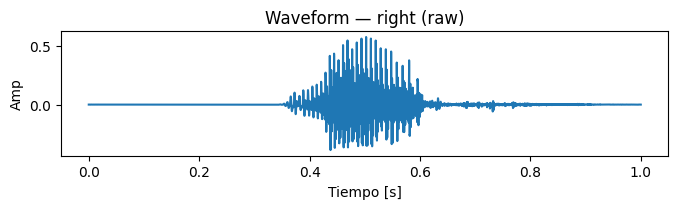

Clase: go | sr: 16000 | shape: (1, 16000) | dur: 1.00s


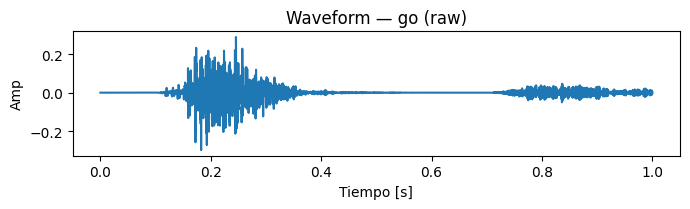

In [ ]:
def plot_waveform(wav, sr, title="Waveform (raw)"):
    """
    Grafica la forma de onda (waveform) de un audio en función del tiempo
    """
    x = wav.squeeze().cpu().numpy()   # Convertir a numpy para graficar
    t = np.arange(len(x))/sr          # Eje temporal en segundos

    plt.figure(figsize=(7, 2.2))
    plt.plot(t, x)
    plt.xlabel("Tiempo [s]"); plt.ylabel("Amp"); plt.title(title)
    plt.tight_layout(); plt.show()

# Visualización de ejemplos aleatorios
for _ in range(2):
    idx = random.randrange(len(train_ds))
    wav, sr, y = train_ds[idx]
    print(f"Clase: {CLASSES[y]} | sr: {sr} | shape: {tuple(wav.shape)} | dur: {wav.shape[-1]/sr:.2f}s")
    plot_waveform(wav, sr, title=f"Waveform — {CLASSES[y]} (raw)")


Transformación a espectograma Log-Mel:

Ejemplo idx=15795 | clase=on | sr=16000 | dur=1.00s


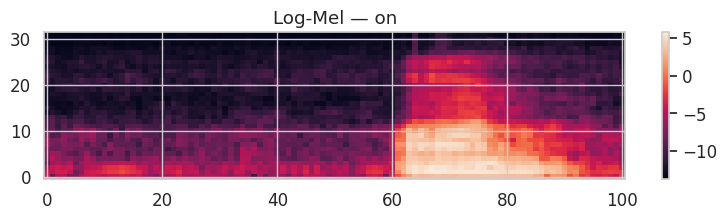

▶️ Reproducir:


In [ ]:
from IPython.display import Audio, display

# Transformación a Mel-Spectrograma
mel_tf_vis = T.MelSpectrogram(
    sample_rate=NATIVE_SR,
    n_fft=N_FFT,
    hop_length=HOP_LENGTH,
    n_mels=N_MELS)

def plot_logmel(wav, sr, title="Log-Mel"):
    """
    Calcula y grafica el espectrograma log-Mel correspondiente a una señal de audio
    """
    with torch.no_grad():
        # Transformación Mel
        M = mel_tf_vis(wav)                     # (1, F, Tm)
        LM = torch.log(M + 1e-6)

        # ajuste de dimensiones para graficar
        if LM.ndim == 3 and LM.shape[0] == 1:   # quitar canal
            LM = LM.squeeze(0)                  # (F, Tm)
        elif LM.ndim == 1:
            LM = LM.unsqueeze(0)
        LM = LM.cpu().numpy()

    # Visualización
    plt.figure(figsize=(8, 2.4))
    plt.imshow(LM, aspect='auto', origin='lower')
    plt.title(title); plt.colorbar(); plt.tight_layout(); plt.show()

# Función para reproducir audio crudo
def play_audio(wav, sr):
    """
    Permite escuchar un ejemplo de audio directamente desde la notebook
    """
    x = wav.squeeze().cpu().numpy()
    display(Audio(x, rate=sr))

# Ejemplo aleatorio
idx = np.random.randint(len(train_ds))
wav, sr, y = train_ds[idx]
print(f"Ejemplo idx={idx} | clase={CLASSES[y]} | sr={sr} | dur={wav.shape[-1]/sr:.2f}s")

# Gráfico y reproducción
plot_logmel(wav, sr, title=f"Log-Mel — {CLASSES[y]}")
print("▶️ Reproducir:")
play_audio(wav, sr)


# 6. Arquitectura

Definimos la arquitectura base (MLP flexible):

In [ ]:
class FlexibleMLP(nn.Module):
    """
    Implementa un perceptrón multicapa que permite ajustar dinámicamente su profundidad, tamaño de capas y función de activación
    Este modelo se usa como punto de partida para comparar con las redes convolucionales (CNN) luego
    """
    def __init__(
        self,
        in_features: int,
        num_classes: int,
        num_hidden_layers: int = 1,
        hidden_size: int = 128,
        activation: str = "ReLU"
    ):
        """
        Parámtros:
        - in_features: cantidad de características de entrada
        - num_classes: cantidad de clases de salida
        - num_hidden_layers: cantidad de capas ocultas
        - hidden_size: cantidad de neuronas por capa oculta
        - activation: función de activación a usar
        """
        super(FlexibleMLP, self).__init__()

        # Validamos que la función de activación exista en torch.nn
        if not hasattr(nn, activation):
            raise ValueError(f"La activación '{activation}' no existe en torch.nn")
        act_layer = getattr(nn, activation)

        layers = []
        input_dim = in_features

        # Capas ocultas
        for _ in range(num_hidden_layers):
            layers.append(nn.Linear(input_dim, hidden_size))
            layers.append(act_layer())
            input_dim = hidden_size

        # Capa de salida
        layers.append(nn.Linear(input_dim, num_classes))

        # Se define la red completa como una secuencia de capas
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        # Si la entrada tiene más de 2 dimensiones, se aplana automáticamente
        if x.ndim > 2:
            x = x.view(x.size(0), -1)
        return self.net(x)

Definimos función de entrenamiento de modelos:

Esta misma función se utiliza a lo largo de todos los incisos del trabajo práctico, por lo que los nombres de los experimentos ("run_name") se construyen dinámicamente a partir de los hiperparámetros incluidos en el diccionario "config"

In [ ]:
def train_model(model, train_loader, val_loader, criterion, optimizer, device, config, project_name="TP3_Audio"):
    """
    Entrena un modelo y registra métricas (loss y accuracy) en Weights & Biases
    """
    # Detectar tipo de experimento y construir nombre

    # Caso CNN con tupla de filtros (f1, f2, f3)
    if all(k in config for k in ("filters", "kernel_size", "linear_dim")):
        f_str = "-".join(str(f) for f in config["filters"])
        run_name = (
            f"{config['input_type']}_{config['model']}_{config['activation']}_"
            f"f{f_str}_k{config['kernel_size']}_lin{config['linear_dim']}_lr{config['lr']}"
        )

    # Regularización (Dropout + Weight Decay)
    elif any(k in config for k in ("dropout_p", "weight_decay")):
        dropout_str = f"do{config.get('dropout_p', 0)}"
        wd_str = f"wd{config.get('weight_decay', 0)}"
        run_name = (
            f"{config['input_type']}_{config['model']}_{config['activation']}_"
            f"{dropout_str}_{wd_str}_bs{config['batch_size']}_ep{config['epochs']}_lr{config['lr']}"
        )

    # Experimentos de entrenamiento (batch_size + epochs)
    elif all(k in config for k in ("batch_size", "epochs")):
        run_name = (
            f"{config['input_type']}_{config['model']}_{config['activation']}_"
            f"bs{config['batch_size']}_ep{config['epochs']}_lr{config['lr']}"
        )

    # Caso general con optimizer y scheduler
    elif all(k in config for k in ("optimizer", "scheduler", "input_type", "activation")):
        run_name = (
            f"{config['input_type']}_{config['model']}_{config['activation']}_"
            f"{config['optimizer']}_sched-{config['scheduler']}_lr{config['lr']}"
        )

    # Caso sin scheduler
    elif all(k in config for k in ("optimizer", "input_type", "activation")):
        run_name = (
            f"{config['input_type']}_{config['model']}_{config['activation']}_"
            f"{config['optimizer']}_lr{config['lr']}"
        )

    # Caso mínimo
    elif all(k in config for k in ("input_type", "activation")):
        run_name = f"{config['input_type']}_{config['model']}_{config['activation']}_lr{config['lr']}"
    else:
        run_name = f"{config['model']}_lr{config['lr']}"

    # Agregar info de optimizador / scheduler si existen
    if "optimizer" in config:
        run_name += f"_{config['optimizer']}"
    if "scheduler" in config:
        run_name += f"_sched-{config['scheduler']}"

    # Inicializa run en Weights & Biases
    with wandb.init(project=project_name, name=run_name, config=config):
        model = model.to(device)

        # Loop principal de entrenamiento
        for epoch in range(config['epochs']):
            model.train()
            train_loss, train_correct, train_total = 0, 0, 0

            # Entrenamiento
            for X, y in train_loader:
                X, y = X.to(device), y.to(device)
                optimizer.zero_grad()
                logits = model(X)
                loss = criterion(logits, y)
                loss.backward()
                optimizer.step()

                # Métricas
                train_loss += loss.item() * y.size(0)
                train_correct += (logits.argmax(1) == y).sum().item()
                train_total += y.size(0)

            train_acc = train_correct / train_total
            train_loss /= train_total

            # Validación
            model.eval()
            val_loss, val_correct, val_total = 0, 0, 0
            with torch.no_grad():
                for X, y in val_loader:
                    X, y = X.to(device), y.to(device)
                    logits = model(X)
                    loss = criterion(logits, y)
                    val_loss += loss.item() * y.size(0)
                    val_correct += (logits.argmax(1) == y).sum().item()
                    val_total += y.size(0)

            val_acc = val_correct / val_total
            val_loss /= val_total

            wandb.log({
                "epoch": epoch + 1,
                "train_loss": train_loss,
                "train_acc": train_acc,
                "val_loss": val_loss,
                "val_acc": val_acc
            })

            print(f"Epoch {epoch+1}/{config['epochs']} | Train acc={train_acc:.3f} | Val acc={val_acc:.3f}")

        # Guardar modelo entrenado
        model_path = f"{run_name}.pt"
        torch.save(model.state_dict(), model_path)
        wandb.save(model_path)  # Lo sube al dashboard de W&B

Configuración inicial para los experimentos:



In [ ]:
# Configuración base
BASE_CONFIG = {
    "model": "MLP",
    "activation": "ReLU",
    "lr": LR,
    "epochs": 15,   # 15 epochs son suficientes para observar tendencias (y no perder en cómputo)
    "batch_size": BATCH_SIZE
}

# Conjuntos de valores a probar
hidden_layers_options = [1, 2, 3, 4]        # Cantidad de capas ocultas
hidden_size_options = [64, 128, 256, 512]   # Cantidad de neuronas por capa

# Registro de resultados
results = []

Entrenamiento de las múltiples combinaciones con MLP:

In [ ]:
for nl in hidden_layers_options:
    for hs in hidden_size_options:

        # Configuración de hiperparámetros actual
        config = {**BASE_CONFIG, "num_hidden_layers": nl, "hidden_size": hs}
        run_name = f"MLP_L{nl}_H{hs}_{config['activation']}_lr{config['lr']}"

        print(f"\n Entrenando arquitectura: {run_name}")

        # Inicialización del modelo con la configuración actual
        model = FlexibleMLP(
            in_features=in_features,
            num_classes=num_classes,
            num_hidden_layers=nl,
            hidden_size=hs,
            activation=config["activation"]
        ).to(DEVICE)

        # Optimizador y pérdida
        optimizer = torch.optim.Adam(model.parameters(), lr=config["lr"])
        criterion = nn.CrossEntropyLoss()

        # Entrenamiento + registro en W&B
        train_model(model, train_loader, val_loader, criterion, optimizer, DEVICE, config)
        wandb.finish()

        # Evaluación final sobre el conjunto de validación
        model.eval()
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for X, y in val_loader:
                X, y = X.to(DEVICE), y.to(DEVICE)
                pred = model(X).argmax(1)
                val_correct += (pred == y).sum().item()
                val_total += y.size(0)

        val_acc = val_correct / val_total
        print(f"Val Accuracy: {val_acc:.3f}")

        # Guardamos resultados parciales
        results.append((nl, hs, val_acc))

        # Mostramos los mejores resultados ordenados por accuracy
        results_df = pd.DataFrame(results, columns=["num_hidden_layers", "hidden_size", "val_acc"])
        display(results_df.sort_values("val_acc", ascending=False).head())


 Entrenando arquitectura: MLP_L1_H64_ReLU_lr0.001


Epoch 1/15 | Train acc=0.125 | Val acc=0.129
Epoch 2/15 | Train acc=0.268 | Val acc=0.135
Epoch 3/15 | Train acc=0.381 | Val acc=0.138
Epoch 4/15 | Train acc=0.487 | Val acc=0.143
Epoch 5/15 | Train acc=0.573 | Val acc=0.149
Epoch 6/15 | Train acc=0.643 | Val acc=0.144
Epoch 7/15 | Train acc=0.705 | Val acc=0.148
Epoch 8/15 | Train acc=0.752 | Val acc=0.142
Epoch 9/15 | Train acc=0.792 | Val acc=0.143
Epoch 10/15 | Train acc=0.825 | Val acc=0.142
Epoch 11/15 | Train acc=0.850 | Val acc=0.140
Epoch 12/15 | Train acc=0.870 | Val acc=0.147
Epoch 13/15 | Train acc=0.880 | Val acc=0.144
Epoch 14/15 | Train acc=0.895 | Val acc=0.141
Epoch 15/15 | Train acc=0.911 | Val acc=0.139


epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
train_acc,▁▂▃▄▅▆▆▇▇▇▇████
train_loss,█▇▆▅▄▄▃▃▂▂▂▁▁▁▁
val_acc,▁▃▄▆█▆█▆▆▆▅▇▆▅▄
val_loss,▁▁▁▂▂▃▃▄▄▅▆▆▇██
epoch,15
train_acc,0.91053
train_loss,0.401
val_acc,0.13854
val_loss,5.56162


Val Accuracy: 0.139


,num_hidden_layers,hidden_size,val_acc
0,1,64,0.138536


...


 Entrenando arquitectura: MLP_L4_H512_ReLU_lr0.001


Epoch 1/15 | Train acc=0.119 | Val acc=0.124
Epoch 2/15 | Train acc=0.172 | Val acc=0.153
Epoch 3/15 | Train acc=0.256 | Val acc=0.150
Epoch 4/15 | Train acc=0.382 | Val acc=0.150
Epoch 5/15 | Train acc=0.525 | Val acc=0.147
Epoch 6/15 | Train acc=0.679 | Val acc=0.147
Epoch 7/15 | Train acc=0.791 | Val acc=0.157
Epoch 8/15 | Train acc=0.866 | Val acc=0.147
Epoch 9/15 | Train acc=0.908 | Val acc=0.150
Epoch 10/15 | Train acc=0.929 | Val acc=0.158
Epoch 11/15 | Train acc=0.943 | Val acc=0.163
Epoch 12/15 | Train acc=0.954 | Val acc=0.155
Epoch 13/15 | Train acc=0.957 | Val acc=0.143
Epoch 14/15 | Train acc=0.961 | Val acc=0.152
Epoch 15/15 | Train acc=0.969 | Val acc=0.154


epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
train_acc,▁▁▂▃▄▆▇▇▇██████
train_loss,██▇▆▅▃▃▂▂▁▁▁▁▁▁
val_acc,▁▆▆▆▅▅▇▅▆▇█▇▅▆▇
val_loss,▁▁▁▁▂▃▄▅▆▆▇▇▇▇█
epoch,15
train_acc,0.9688
train_loss,0.10281
val_acc,0.15447
val_loss,8.5383


Val Accuracy: 0.154


,num_hidden_layers,hidden_size,val_acc
3,1,512,0.169862
2,1,256,0.167162
4,2,64,0.164191
5,2,128,0.160951
9,3,128,0.160410


Selección del mejor y peor experimento:

In [ ]:
def get_best_hparams(results_df):
    """
    Identifica y muestra los hiperparámetros del mejor y peor experimento, basándose en la precisión de validación (val_acc)
    """
    # Localiza las filas con mejor y peor desempeño
    best_row = results_df.loc[results_df["val_acc"].idxmax()]
    worst_row = results_df.loc[results_df["val_acc"].idxmin()]

    # Diccionarios con hiperparámetros
    best_hparams = {
        "num_hidden_layers": int(best_row["num_hidden_layers"]),
        "hidden_size": int(best_row["hidden_size"]),
        "val_acc": float(best_row["val_acc"])
    }

    worst_hparams = {
        "num_hidden_layers": int(worst_row["num_hidden_layers"]),
        "hidden_size": int(worst_row["hidden_size"]),
        "val_acc": float(worst_row["val_acc"])
    }

    # Prints
    print("Mejor configuración encontrada:")
    print(f"   - num_hidden_layers = {best_hparams['num_hidden_layers']}")
    print(f"   - hidden_size       = {best_hparams['hidden_size']}")
    print(f"   - val_acc           = {best_hparams['val_acc']:.3f}\n")

    print("Peor configuración encontrada:")
    print(f"   - num_hidden_layers = {worst_hparams['num_hidden_layers']}")
    print(f"   - hidden_size       = {worst_hparams['hidden_size']}")
    print(f"   - val_acc           = {worst_hparams['val_acc']:.3f}")

    return best_hparams

# Identificamos el mejor modelo
best = get_best_hparams(results_df)

# 7. MEL vs. WAV - MLP & CNN



In [ ]:
# Transformación para convertir audios en espectogramas MEL
mel_tf = T.MelSpectrogram(
    sample_rate=NATIVE_SR,
    n_fft=N_FFT,
    hop_length=HOP_LENGTH,
    n_mels=N_MELS
)

Funciones de collate:

In [ ]:
# WAV (MLP)
def collate_wave_flat(batch):
    """
    Convierte un batch de waveforms de longitud variable en tensores uniformes,
    aplicando padding y aplanado (B, Tmax) para usar en un MLP
    """
    max_len = max(wav.shape[-1] for wav, _, _ in batch)
    padded, ys = [], []
    for wav, sr, y in batch:
        pad_len = max_len - wav.shape[-1]
        if pad_len > 0:
            wav = F.pad(wav, (0, pad_len))    # (1, Tmax)
        padded.append(wav)
        ys.append(y)
    W = torch.stack(padded, dim=0)            # (B, 1, Tmax)
    X = W.flatten(1)                          # (B, Tmax)
    y = torch.tensor(ys, dtype=torch.long)
    return X, y

# WAV (CNN)
def collate_wave_2d(batch):
    """
    Similar al anterior, pero conserva la estructura 2D (B, 1, 1, Tmax),
    para que las convoluciones se apliquen sobre el eje temporal
    """
    max_len = max(wav.shape[-1] for wav, _, _ in batch)
    padded, ys = [], []
    for wav, sr, y in batch:
        pad_len = max_len - wav.shape[-1]
        if pad_len > 0:
            wav = F.pad(wav, (0, pad_len))
        padded.append(wav)
        ys.append(y)
    X = torch.stack(padded, dim=0).unsqueeze(2)  # (B, 1, 1, Tmax)
    y = torch.tensor(ys, dtype=torch.long)
    return X, y

# MEL (MLP)
def collate_mel_flat(batch):
    """
    Convierte cada audio a un espectrograma Mel, aplica padding temporal
    y aplana el resultado para usarlo en un MLP → (B, n_mels*Tmax)
    """
    mel_batch, ys = [], []
    max_len = 0
    for wav, sr, y in batch:
        M = mel_tf(wav)  # (1, n_mels, t_frames)
        max_len = max(max_len, M.shape[-1])
        mel_batch.append(M)
        ys.append(y)

    padded = []
    for M in mel_batch:
        pad_len = max_len - M.shape[-1]
        if pad_len > 0:
            M = F.pad(M, (0, pad_len))
        padded.append(M)

    X = torch.stack(padded, dim=0).flatten(1)  # (B, n_mels*Tmax)
    y = torch.tensor(ys, dtype=torch.long)
    return X, y

# MEL (CNN)
def collate_mel_2d(batch):
    """
    Convierte cada audio a un espectrograma Mel 2D (B, 1, n_mels, Tmax),
    manteniendo su estructura tiempo-frecuencia para convoluciones 2D
    """
    max_len = max(mel_tf(wav).shape[-1] for wav, _, _ in batch)
    padded, ys = [], []
    for wav, sr, y in batch:
        M = mel_tf(wav)
        pad_len = max_len - M.shape[-1]
        if pad_len > 0:
            M = F.pad(M, (0, pad_len))
        padded.append(M)
        ys.append(y)
    X = torch.stack(padded, dim=0)  # (B, 1, n_mels, Tmax)
    y = torch.tensor(ys, dtype=torch.long)
    return X, y

Creación de DataLoaders para los distintos escenarios:

In [ ]:
# WAV (MLP)
train_loader_wav = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_wave_flat)
val_loader_wav   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_wave_flat)

# WAV (CNN)
train_loader_wav_2d = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_wave_2d)
val_loader_wav_2d   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_wave_2d)

# MEL (MLP)
train_loader_mel_flat = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_mel_flat)
val_loader_mel_flat   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_mel_flat)

# MEL (CNN)
train_loader_mel_2d = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_mel_2d)
val_loader_mel_2d   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_mel_2d)

print("DataLoaders listos:")
print("- WAV --> MLP:", len(train_loader_wav))
print("- WAV --> CNN:", len(train_loader_wav_2d))
print("- MEL --> MLP:", len(train_loader_mel_flat))
print("- MEL --> CNN:", len(train_loader_mel_2d))

DataLoaders listos:
- WAV → MLP: 241
- WAV → CNN: 241
- MEL → MLP: 241
- MEL → CNN: 241


Definición de modelos convolucionales:

In [ ]:
# CNN 1D (en realidad implementada con Conv2d) aplicada sobre señales WAV
class SimpleCNN1D(nn.Module):
    """
    Red convolucional simple que trabaja directamente sobre las formas de onda (WAV)
    Utiliza convoluciones con kernel temporal para capturar patrones locales de energía
    """
    def __init__(self, num_classes):
        super(SimpleCNN1D, self).__init__()

        # Bloque convolucional
        self.features = nn.Sequential(
            nn.Conv2d(1, 8, (1, 9), stride=(1, 2), padding=(0, 4)), nn.ReLU(),
            nn.Conv2d(8, 16, (1, 9), stride=(1, 2), padding=(0, 4)), nn.ReLU(),
            nn.MaxPool2d((1, 4))
        )

        # Determinamos automáticamente la dimensión de salida
        with torch.no_grad():
            dummy = torch.zeros(1, 1, 1, 16000)  # audio típico (1s)
            out = self.features(dummy)
            self.flat_dim = out.numel()

        # Clasificador denso
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(self.flat_dim, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# CNN 2D aplicada sobre espectogramas MEL
class SimpleCNN2D(nn.Module):
    """
    Red convolucional 2D que opera sobre espectrogramas log-Mel
    Aprende patrones combinados de frecuencia y tiempo, siendo más adecuada
    para reconocimiento de voz o audio
    """
    def __init__(self, num_classes):
        super(SimpleCNN2D, self).__init__()

        # Bloque convolucional 2D (tiempo-frecuencia)
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2)
        )

        # Cálculo automático del tamaño de salida
        with torch.no_grad():
            dummy = torch.zeros(1, 1, N_MELS, 100)
            out = self.features(dummy)
            self.flat_dim = out.numel()

        # Clasificador totalmente conectado
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(self.flat_dim, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [ ]:
# Configuración base (usando la mejor del inciso anterior)
BASE_CONFIG = {
    "activation": "ReLU",
    "num_hidden_layers": best["num_hidden_layers"],
    "hidden_size": best["hidden_size"],
    "lr": 1e-3,
    "epochs": 15,
    "batch_size": BATCH_SIZE
}

criterion = nn.CrossEntropyLoss()

NameError: name 'best' is not defined

Entrenamiento de los 4 escenarios:

In [ ]:
# WAV (MLP)
cfg_wav_mlp = {**BASE_CONFIG, "input_type": "WAV", "model": "MLP"}
xb_wav, _ = next(iter(train_loader_wav))
model_wav_mlp = FlexibleMLP(
    in_features=xb_wav.shape[1],
    num_classes=len(CLASSES),
    num_hidden_layers=BASE_CONFIG["num_hidden_layers"],
    hidden_size=BASE_CONFIG["hidden_size"],
    activation=BASE_CONFIG["activation"]
)
optimizer = torch.optim.Adam(model_wav_mlp.parameters(), lr=BASE_CONFIG["lr"])
train_model(model_wav_mlp, train_loader_wav, val_loader_wav, criterion, optimizer, DEVICE, cfg_wav_mlp)

# MEL (MLP)
cfg_mel_mlp = {**BASE_CONFIG, "input_type": "MEL", "model": "MLP"}
xb_mel, _ = next(iter(train_loader_mel_flat))
model_mel_mlp = FlexibleMLP(
    in_features=xb_mel.shape[1],
    num_classes=len(CLASSES),
    num_hidden_layers=BASE_CONFIG["num_hidden_layers"],
    hidden_size=BASE_CONFIG["hidden_size"],
    activation=BASE_CONFIG["activation"]
)
optimizer = torch.optim.Adam(model_mel_mlp.parameters(), lr=BASE_CONFIG["lr"])
train_model(model_mel_mlp, train_loader_mel_flat, val_loader_mel_flat, criterion, optimizer, DEVICE, cfg_mel_mlp)

# WAV (CNN)
cfg_wav_cnn = {"input_type": "WAV", "model": "CNN", "lr": 1e-3, "epochs": 15}
model_wav_cnn = SimpleCNN1D(num_classes=len(CLASSES))
optimizer = torch.optim.Adam(model_wav_cnn.parameters(), lr=cfg_wav_cnn["lr"])
train_model(model_wav_cnn, train_loader_wav_2d, val_loader_wav_2d, criterion, optimizer, DEVICE, cfg_wav_cnn)

# MEL (CNN)
cfg_mel_cnn = {"input_type": "MEL", "model": "CNN", "lr": 1e-3, "epochs": 15}
model_mel_cnn = SimpleCNN2D(num_classes=len(CLASSES))
optimizer = torch.optim.Adam(model_mel_cnn.parameters(), lr=cfg_mel_cnn["lr"])
train_model(model_mel_cnn, train_loader_mel_2d, val_loader_mel_2d, criterion, optimizer, DEVICE, cfg_mel_cnn)

Epoch 1/15 | Train acc=0.217 | Val acc=0.358
Epoch 2/15 | Train acc=0.456 | Val acc=0.488
Epoch 3/15 | Train acc=0.574 | Val acc=0.549
Epoch 4/15 | Train acc=0.652 | Val acc=0.608
Epoch 5/15 | Train acc=0.712 | Val acc=0.619
Epoch 6/15 | Train acc=0.764 | Val acc=0.635
Epoch 7/15 | Train acc=0.803 | Val acc=0.637
Epoch 8/15 | Train acc=0.838 | Val acc=0.648
Epoch 9/15 | Train acc=0.870 | Val acc=0.653
Epoch 10/15 | Train acc=0.900 | Val acc=0.651
Epoch 11/15 | Train acc=0.921 | Val acc=0.647
Epoch 12/15 | Train acc=0.935 | Val acc=0.648
Epoch 13/15 | Train acc=0.942 | Val acc=0.648
Epoch 14/15 | Train acc=0.955 | Val acc=0.641
Epoch 15/15 | Train acc=0.969 | Val acc=0.642


epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
train_acc,▁▃▄▅▆▆▆▇▇▇█████
train_loss,█▆▅▄▄▃▃▂▂▂▁▁▁▁▁
val_acc,▁▄▆▇▇██████████
val_loss,▇▄▂▁▁▁▁▂▂▃▄▅▆▇█
epoch,15
train_acc,0.96948
train_loss,0.11899
val_acc,0.64191
val_loss,1.9922


Epoch 1/15 | Train acc=0.405 | Val acc=0.543
Epoch 2/15 | Train acc=0.671 | Val acc=0.683
Epoch 3/15 | Train acc=0.768 | Val acc=0.726
Epoch 4/15 | Train acc=0.815 | Val acc=0.755
Epoch 5/15 | Train acc=0.856 | Val acc=0.761
Epoch 6/15 | Train acc=0.880 | Val acc=0.781
Epoch 7/15 | Train acc=0.886 | Val acc=0.777
Epoch 8/15 | Train acc=0.906 | Val acc=0.786
Epoch 9/15 | Train acc=0.925 | Val acc=0.790
Epoch 10/15 | Train acc=0.935 | Val acc=0.786
Epoch 11/15 | Train acc=0.939 | Val acc=0.788
Epoch 12/15 | Train acc=0.935 | Val acc=0.795
Epoch 13/15 | Train acc=0.937 | Val acc=0.804
Epoch 14/15 | Train acc=0.941 | Val acc=0.801
Epoch 15/15 | Train acc=0.956 | Val acc=0.810


epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
train_acc,▁▄▆▆▇▇▇▇███████
train_loss,█▅▃▃▂▂▂▂▁▁▁▁▁▁▁
val_acc,▁▅▆▇▇▇▇▇▇▇▇████
val_loss,▇▃▂▁▃▃▃▄▅▇█▆▆█▇
epoch,15
train_acc,0.95648
train_loss,0.14534
val_acc,0.81042
val_loss,1.51274


# 8. Funciones de activación

Evaluamos el impacto de distintas funciones de activación sobre el desempeño de CNN:

In [ ]:
# Definimos ShiftedReLU (no está en torch.nn)
class ShiftedReLU(nn.Module):
    """
    La ShiftedReLU desplaza el umbral de activación hacia la derecha,
    activando solo cuando x > shift (en lugar de x > 0)
    Matemáticamente: f(x) = ReLU(x - shift)
    """
    def __init__(self, shift=1.0):
        super().__init__()
        self.shift = shift

    def forward(self, x):
        return torch.relu(x - self.shift)

# Agregamos manualmente al espacio de nombres de torch.nn
nn.ShiftedReLU = ShiftedReLU

Funciones de activación a comparar:

In [ ]:
activations = [
    "ReLU",           # Estándar, rápida y efectiva
    "LeakyReLU",      # Evita el problema ReLU muerta
    "ShiftedReLU",    # Versión desplazada definida arriba
    "Tanh",           # Compresora simétrica (-1, 1)
    "Sigmoid",        # Saturante, útil en capas finales
    "ELU",            # Suaviza la zona negativa
    "SiLU"            # Variante suave de ReLU (swish)
]

In [ ]:
# Reutilizamos la mejor arquitectura obtenida previamente
BASE_CONFIG = {
    "model": "CNN",
    "input_type": "MEL",
    "activation": "ReLU",
    "num_hidden_layers": best["num_hidden_layers"],
    "hidden_size": best["hidden_size"],
    "lr": 1e-3,
    "epochs": 15,
    "batch_size": BATCH_SIZE
}
criterion = nn.CrossEntropyLoss()

activation_results = []

Modificación de SimpleCNN2D para permitir especificar la función de activación:

In [ ]:
class SimpleCNN2D_Act(nn.Module):
    def __init__(self, num_classes, activation="ReLU"):
        super(SimpleCNN2D_Act, self).__init__()

        # Verificamos que la activación exista dentro de torch.nn
        if not hasattr(nn, activation):
            raise ValueError(f"La activación '{activation}' no existe en torch.nn")
        act = getattr(nn, activation)

        # Bloque convolucional (dos capas con pooling)
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), act(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), act(), nn.MaxPool2d(2)
        )

        # Cálculo automático del tamaño de entrada al clasificador
        with torch.no_grad():
            dummy = torch.zeros(1, 1, N_MELS, 100)
            out = self.features(dummy)
            self.flat_dim = out.numel()

        # Clasificador final
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(self.flat_dim, 128),
            act(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

Entrenamiento iterando sobre las distintas activaciones:

In [ ]:
for act in activations:
    print(f"\nEntrenando CNN (MEL) con activación: {act}")

    # Se actualiza la configuración para cada activación
    config = {**BASE_CONFIG, "activation": act}

    # Inicialización del modelo con la activación seleccionada
    model = SimpleCNN2D_Act(num_classes=len(CLASSES), activation=act).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=config["lr"])

    try:
        # Entrenamiento y registro en W&B
        train_model(model, train_loader_mel_2d, val_loader_mel_2d, criterion, optimizer, DEVICE, config)
        wandb.finish()
    except Exception as e:
        # Si alguna falla, se sigue con la siguiente
        print(f"Error con {act}: {e}")
        wandb.finish()
        continue

    # Evaluación final en el conjunto de validación
    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for X, y in val_loader_mel_2d:
            X, y = X.to(DEVICE), y.to(DEVICE)
            pred = model(X).argmax(1)
            val_correct += (pred == y).sum().item()
            val_total += y.size(0)
    val_acc = val_correct / val_total

    print(f"Val Accuracy ({act}): {val_acc:.3f}")
    activation_results.append((act, val_acc))

# Almacenamos y visualizamos los resultados ordenados por accuracy
activation_df = pd.DataFrame(activation_results, columns=["activation", "val_acc"])
display(activation_df.sort_values("val_acc", ascending=False))


 Entrenando CNN (MEL) con activación: ReLU


Epoch 1/15 | Train acc=0.375 | Val acc=0.581
Epoch 2/15 | Train acc=0.666 | Val acc=0.681
Epoch 3/15 | Train acc=0.762 | Val acc=0.730
Epoch 4/15 | Train acc=0.815 | Val acc=0.726
Epoch 5/15 | Train acc=0.849 | Val acc=0.778
Epoch 6/15 | Train acc=0.882 | Val acc=0.773
Epoch 7/15 | Train acc=0.889 | Val acc=0.784
Epoch 8/15 | Train acc=0.890 | Val acc=0.807
Epoch 9/15 | Train acc=0.923 | Val acc=0.790
Epoch 10/15 | Train acc=0.918 | Val acc=0.794
Epoch 11/15 | Train acc=0.932 | Val acc=0.802
Epoch 12/15 | Train acc=0.948 | Val acc=0.808
Epoch 13/15 | Train acc=0.958 | Val acc=0.809
Epoch 14/15 | Train acc=0.961 | Val acc=0.794
Epoch 15/15 | Train acc=0.952 | Val acc=0.813


epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
train_acc,▁▄▆▆▇▇▇▇█▇█████
train_loss,█▅▃▃▂▂▂▂▁▂▁▁▁▁▁
val_acc,▁▄▆▅▇▇▇█▇▇███▇█
val_loss,▆▃▂▂▁▃▃▁▄▄▄▄▆█▇
epoch,15
train_acc,0.95242
train_loss,0.15816
val_acc,0.81339
val_loss,1.45657


Val Accuracy (ReLU): 0.813

 Entrenando CNN (MEL) con activación: LeakyReLU


Epoch 1/15 | Train acc=0.431 | Val acc=0.557
Epoch 2/15 | Train acc=0.679 | Val acc=0.672
Epoch 3/15 | Train acc=0.772 | Val acc=0.725
Epoch 4/15 | Train acc=0.821 | Val acc=0.730
Epoch 5/15 | Train acc=0.856 | Val acc=0.776
Epoch 6/15 | Train acc=0.877 | Val acc=0.772
Epoch 7/15 | Train acc=0.901 | Val acc=0.794
Epoch 8/15 | Train acc=0.910 | Val acc=0.793
Epoch 9/15 | Train acc=0.911 | Val acc=0.797
Epoch 10/15 | Train acc=0.922 | Val acc=0.782
Epoch 11/15 | Train acc=0.922 | Val acc=0.793
Epoch 12/15 | Train acc=0.944 | Val acc=0.806
Epoch 13/15 | Train acc=0.960 | Val acc=0.813
Epoch 14/15 | Train acc=0.965 | Val acc=0.812
Epoch 15/15 | Train acc=0.968 | Val acc=0.812


...

epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
train_acc,▁▅▆▇▇▇▇████████
train_loss,█▄▃▂▂▂▁▁▁▁▁▁▁▁▁
val_acc,▁▅▆▆▇▇▇▇▇▇▇█▇█▇
val_loss,▄▁▁▁▂▂▄▄▅▅▆▅▇▆█
epoch,15
train_acc,0.96815
train_loss,0.11853
val_acc,0.81231
val_loss,1.3195


Val Accuracy (ELU): 0.812

 Entrenando CNN (MEL) con activación: SiLU


Epoch 1/15 | Train acc=0.425 | Val acc=0.540
Epoch 2/15 | Train acc=0.690 | Val acc=0.678
Epoch 3/15 | Train acc=0.776 | Val acc=0.701
Epoch 4/15 | Train acc=0.827 | Val acc=0.746
Epoch 5/15 | Train acc=0.863 | Val acc=0.763
Epoch 6/15 | Train acc=0.885 | Val acc=0.769
Epoch 7/15 | Train acc=0.888 | Val acc=0.788
Epoch 8/15 | Train acc=0.912 | Val acc=0.776
Epoch 9/15 | Train acc=0.935 | Val acc=0.762
Epoch 10/15 | Train acc=0.933 | Val acc=0.778
Epoch 11/15 | Train acc=0.945 | Val acc=0.797
Epoch 12/15 | Train acc=0.961 | Val acc=0.801
Epoch 13/15 | Train acc=0.965 | Val acc=0.792
Epoch 14/15 | Train acc=0.951 | Val acc=0.792
Epoch 15/15 | Train acc=0.961 | Val acc=0.791


epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
train_acc,▁▄▆▆▇▇▇▇███████
train_loss,█▅▄▃▂▂▂▂▁▁▁▁▁▁▁
val_acc,▁▅▅▇▇▇█▇▇▇█████
val_loss,▄▁▁▁▂▂▂▄▄▅▅▆▇▇█
epoch,15
train_acc,0.96132
train_loss,0.13376
val_acc,0.79125
val_loss,1.76864


Val Accuracy (SiLU): 0.791


In [ ]:
# Mejor y peor experimento
best_act = activation_df.loc[activation_df["val_acc"].idxmax()]
worst_act = activation_df.loc[activation_df["val_acc"].idxmin()]

print("\nMejor activación:")
print(f"   {best_act['activation']} — Val Acc: {best_act['val_acc']:.3f}")

print("\nPeor activación:")
print(f"   {worst_act['activation']} — Val Acc: {worst_act['val_acc']:.3f}")

,activation,val_acc
3,Tanh,0.844991
0,ReLU,0.813395
1,LeakyReLU,0.812314
5,ELU,0.812314
6,SiLU,0.791250
2,ShiftedReLU,0.788280
4,Sigmoid,0.637861



Mejor activación:
   Tanh — Val Acc: 0.845

Peor activación:
   Sigmoid — Val Acc: 0.638


# 9. Optimizadores

In [ ]:
# Utilizamos la mejor configuración encontrada hasta el momento
BASE_CONFIG = {
    "model": "CNN",
    "input_type": "MEL",
    "activation": "Tanh",
    "num_hidden_layers": 1,
    "hidden_size": 512,
    "lr": 1e-3,
    "epochs": 15,
    "batch_size": BATCH_SIZE
}
criterion = nn.CrossEntropyLoss()

Comparamos el desempeño de distintos algoritmos de optimización sobre la CNN 2D con MEL:

In [ ]:
# Optimizadores para comparar
optimizers = [
    ("BGD", torch.optim.SGD, 1024),             # Usamos un batch grande en lugar de todo el dataset por cuestiones de cómputo
    ("SGD", torch.optim.SGD, 32),               # Batch pequeño
    ("MiniBatch", torch.optim.SGD, 128),
    ("Adagrad", torch.optim.Adagrad, 128),
    ("Adadelta", torch.optim.Adadelta, 128),
    ("RMSprop", torch.optim.RMSprop, 128),
    ("Adam", torch.optim.Adam, 128)

]
optimizer_results = []

Entrenamiento iterando sobre cada optimizador:

In [ ]:
for opt_name, opt_class, batch_size in optimizers:
    print(f"\nEntrenando con {opt_name} (batch_size={batch_size})")

    config = {**BASE_CONFIG, "optimizer": opt_name, "batch_size": batch_size}

    # Redefinimos los dataloaders para reflejar el nuevo batch_size
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, collate_fn=collate_mel_2d)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, collate_fn=collate_mel_2d)

    # Inicializamos el modelo y el optimizador correspondiente
    model = SimpleCNN2D_Act(num_classes=len(CLASSES), activation=config["activation"]).to(DEVICE)
    optimizer = opt_class(model.parameters(), lr=config["lr"])

    # Entrenamiento y registro en W&B
    train_model(model, train_loader, val_loader, criterion, optimizer, DEVICE, config)
    wandb.finish()

    # Evaluación final en el conjunto de validación
    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for X, y in val_loader:
            X, y = X.to(DEVICE), y.to(DEVICE)
            pred = model(X).argmax(1)
            val_correct += (pred == y).sum().item()
            val_total += y.size(0)

    val_acc = val_correct / val_total
    print(f"Val Accuracy ({opt_name}): {val_acc:.3f}")

    optimizer_results.append((opt_name, batch_size, val_acc))


Entrenando con RMSprop (batch_size=128)


Epoch 1/15 | Train acc=0.555 | Val acc=0.734
Epoch 2/15 | Train acc=0.787 | Val acc=0.765
Epoch 3/15 | Train acc=0.859 | Val acc=0.829
Epoch 4/15 | Train acc=0.903 | Val acc=0.833
Epoch 5/15 | Train acc=0.934 | Val acc=0.860
Epoch 6/15 | Train acc=0.956 | Val acc=0.862
Epoch 7/15 | Train acc=0.972 | Val acc=0.860
Epoch 8/15 | Train acc=0.982 | Val acc=0.844
Epoch 9/15 | Train acc=0.990 | Val acc=0.864
Epoch 10/15 | Train acc=0.993 | Val acc=0.857
Epoch 11/15 | Train acc=0.995 | Val acc=0.856
Epoch 12/15 | Train acc=0.995 | Val acc=0.859
Epoch 13/15 | Train acc=0.997 | Val acc=0.853
Epoch 14/15 | Train acc=0.997 | Val acc=0.860
Epoch 15/15 | Train acc=0.997 | Val acc=0.862


epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
train_acc,▁▅▆▇▇▇█████████
train_loss,█▄▃▃▂▂▂▁▁▁▁▁▁▁▁
val_acc,▁▃▆▆███▇████▇██
val_loss,█▅▂▂▁▁▁▂▁▂▃▃▃▃▃
epoch,15
train_acc,0.99675
train_loss,0.01619
val_acc,0.862
val_loss,0.52604


Val Accuracy (RMSprop): 0.862

Entrenando con Adam (batch_size=128)


Epoch 1/15 | Train acc=0.577 | Val acc=0.725
Epoch 2/15 | Train acc=0.787 | Val acc=0.803
Epoch 3/15 | Train acc=0.857 | Val acc=0.807
Epoch 4/15 | Train acc=0.900 | Val acc=0.839
Epoch 5/15 | Train acc=0.934 | Val acc=0.839
Epoch 6/15 | Train acc=0.957 | Val acc=0.845
Epoch 7/15 | Train acc=0.974 | Val acc=0.851
Epoch 8/15 | Train acc=0.985 | Val acc=0.852
Epoch 9/15 | Train acc=0.991 | Val acc=0.850
Epoch 10/15 | Train acc=0.994 | Val acc=0.851
Epoch 11/15 | Train acc=0.996 | Val acc=0.851
Epoch 12/15 | Train acc=0.997 | Val acc=0.848
Epoch 13/15 | Train acc=0.998 | Val acc=0.851
Epoch 14/15 | Train acc=0.998 | Val acc=0.850
Epoch 15/15 | Train acc=0.998 | Val acc=0.851


epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
train_acc,▁▄▆▆▇▇█████████
train_loss,█▅▃▃▂▂▂▁▁▁▁▁▁▁▁
val_acc,▁▅▆▇▇██████████
val_loss,█▄▃▂▂▁▁▁▂▂▂▂▂▂▃
epoch,15
train_acc,0.99828
train_loss,0.01291
val_acc,0.8512
val_loss,0.54675


Val Accuracy (Adam): 0.851


Comparación y resultados finales:

In [ ]:
opt_df = pd.DataFrame(optimizer_results, columns=["optimizer", "batch_size", "val_acc"])
display(opt_df.sort_values("val_acc", ascending=False))

# Mejor y peor optimizador
best = opt_df.loc[opt_df["val_acc"].idxmax()]
worst = opt_df.loc[opt_df["val_acc"].idxmin()]

print("\nMejor optimizador:")
print(f"   {best['optimizer']} (batch_size={best['batch_size']}) — Val Acc: {best['val_acc']:.3f}")

print("\nPeor optimizador:")
print(f"   {worst['optimizer']} (batch_size={worst['batch_size']}) — Val Acc: {worst['val_acc']:.3f}")

,optimizer,batch_size,val_acc
0,RMSprop,128,0.862004
1,Adam,128,0.851202



Mejor optimizador:
   RMSprop (batch_size=128) — Val Acc: 0.862

Peor optimizador:
   Adam (batch_size=128) — Val Acc: 0.851


# 10. Schedulers

En este caso, utilizamos el mejor optimizador identificado previamente (RMSprop) y probamos varios schedulers:

In [ ]:
# Función de entrenamiento con logging de LR
def train_model_sch(model, train_loader, val_loader, criterion, optimizer, device, config, scheduler=None, project_name="TP3_Audio"):
    """
    Esta versión de la función train_model incorpora registro del learning rate en cada epoch,
    schedulers y entrenamiento extendido a 30 epochs
    """
    run_name = (
        f"{config['input_type']}_{config['model']}_{config['activation']}_"
        f"{config['optimizer']}_sched-{config['scheduler']}_lr{config['lr']}"
    )

    with wandb.init(project=project_name, name=run_name, config=config):
        model = model.to(device)

        for epoch in range(config["epochs"]):
            model.train()
            total_loss, correct, total = 0, 0, 0

            for X, y in train_loader:
                X, y = X.to(device), y.to(device)
                optimizer.zero_grad()
                logits = model(X)
                loss = criterion(logits, y)
                loss.backward()
                optimizer.step()

                total_loss += loss.item() * y.size(0)
                correct += (logits.argmax(1) == y).sum().item()
                total += y.size(0)

            train_acc = correct / total
            avg_loss = total_loss / total

            # Validación
            model.eval()
            val_correct, val_total = 0, 0
            val_loss = 0
            with torch.no_grad():
                for X, y in val_loader:
                    X, y = X.to(device), y.to(device)
                    logits = model(X)
                    loss = criterion(logits, y)
                    val_loss += loss.item() * y.size(0)
                    val_correct += (logits.argmax(1) == y).sum().item()
                    val_total += y.size(0)
            val_acc = val_correct / val_total
            val_loss /= val_total

            # LR actual
            current_lr = optimizer.param_groups[0]["lr"]

            # Loguear métricas y LR en W&B
            wandb.log({
                "epoch": epoch + 1,
                "train_loss": avg_loss,
                "train_acc": train_acc,
                "val_loss": val_loss,
                "val_acc": val_acc,
                "LR (scheduler)": current_lr
            })

            # Mostrar en consola
            print(f"Epoch {epoch+1}/{config['epochs']} | Train acc={train_acc:.3f} | Val acc={val_acc:.3f}")

            # Actualizar scheduler si existe
            if scheduler is not None:
                if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                    scheduler.step(val_loss)
                else:
                    scheduler.step()

        torch.save(model.state_dict(), f"{run_name}.pt")

    return val_acc

Schedulers a comparar:

In [ ]:
# Exponencial
def exponential_decay(opt):
    return ExponentialLR(opt, gamma=0.9)

# Constante
def constant_lr(opt):
    return None  # Sin cambio de LR

# Warmup + Decay
def warmup_then_decay(opt, warmup_epochs=3, gamma=0.9):
    class WarmupExpScheduler:
        def __init__(self, optimizer, warmup_epochs, gamma):
            self.optimizer = optimizer
            self.warmup_epochs = warmup_epochs
            self.gamma = gamma
            self.epoch = 0
        def step(self):
            self.epoch += 1
            if self.epoch <= self.warmup_epochs:
                lr_scale = self.epoch / self.warmup_epochs
            else:
                lr_scale = self.gamma ** (self.epoch - self.warmup_epochs)
            for param_group in self.optimizer.param_groups:
                param_group['lr'] = BASE_CONFIG["lr"] * lr_scale
    return WarmupExpScheduler(opt, warmup_epochs, gamma)

# Basado en error
def reduce_on_plateau(opt):
    return ReduceLROnPlateau(opt, factor=0.5, patience=3)

schedulers = {
    "Constante": constant_lr,
    "Exponencial": exponential_decay,
    "Warmup+Decay": warmup_then_decay,
    "Basado_en_error": reduce_on_plateau
}

scheduler_results = []
BASE_CONFIG.update({"epochs": 30})

Experimento iterando sobre cada scheduler:

In [ ]:
for sch_name, sch_fn in schedulers.items():
    print(f"\nEntrenando con scheduler: {sch_name}")

    # Configuración del experimento
    config = {**BASE_CONFIG, "scheduler": sch_name}
    model = SimpleCNN2D_Act(
        num_classes=len(CLASSES),
        activation=config["activation"]
    ).to(DEVICE)
    optimizer = RMSprop(model.parameters(), lr=config["lr"])
    scheduler = sch_fn(optimizer)

    # Entrenamiento con logging de LR
    best_acc = train_model_sch(
        model=model,
        train_loader=train_loader_mel_2d,
        val_loader=val_loader_mel_2d,
        criterion=criterion,
        optimizer=optimizer,
        device=DEVICE,
        config=config,
        scheduler=scheduler,
        project_name="TP3_Audio"
    )

    wandb.finish()
    scheduler_results.append((sch_name, best_acc))

# Resultados finales
print("\nResultados finales (Scheduler vs Val Accuracy):")
for name, acc in scheduler_results:
    print(f"{name:20s} -> Val Accuracy: {acc:.3f}")


Entrenando con scheduler: Constante


Epoch 1/30 | Train acc=0.600 | Val acc=0.714
Epoch 2/30 | Train acc=0.801 | Val acc=0.784
Epoch 3/30 | Train acc=0.865 | Val acc=0.816
Epoch 4/30 | Train acc=0.905 | Val acc=0.844
Epoch 5/30 | Train acc=0.935 | Val acc=0.845
Epoch 6/30 | Train acc=0.958 | Val acc=0.839
Epoch 7/30 | Train acc=0.973 | Val acc=0.824
Epoch 8/30 | Train acc=0.983 | Val acc=0.829
Epoch 9/30 | Train acc=0.990 | Val acc=0.846
Epoch 10/30 | Train acc=0.993 | Val acc=0.851
Epoch 11/30 | Train acc=0.995 | Val acc=0.846
Epoch 12/30 | Train acc=0.995 | Val acc=0.842
Epoch 13/30 | Train acc=0.997 | Val acc=0.847
Epoch 14/30 | Train acc=0.998 | Val acc=0.847
Epoch 15/30 | Train acc=0.997 | Val acc=0.839
Epoch 16/30 | Train acc=0.997 | Val acc=0.842
Epoch 17/30 | Train acc=0.998 | Val acc=0.845
Epoch 18/30 | Train acc=0.999 | Val acc=0.847
Epoch 19/30 | Train acc=0.997 | Val acc=0.846
Epoch 20/30 | Train acc=0.998 | Val acc=0.845
Epoch 21/30 | Train acc=0.999 | Val acc=0.846
Epoch 22/30 | Train acc=0.998 | Val acc=0.8

LR (scheduler),▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train_acc,▁▅▆▆▇▇████████████████████████
train_loss,█▅▃▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▅▆██▇▇▇██████▇██████▇█▆█▇█▇██
val_loss,▇▄▂▁▁▁▂▂▂▂▂▃▃▄▃▄▄▄▄▄▄▄▅█▅▅▅▆▅▅
LR (scheduler),0.001
epoch,30
train_acc,0.99958
train_loss,0.00257
val_acc,0.84445



Entrenando con scheduler: Exponencial


Epoch 1/30 | Train acc=0.552 | Val acc=0.706
Epoch 2/30 | Train acc=0.787 | Val acc=0.790
Epoch 3/30 | Train acc=0.858 | Val acc=0.785
Epoch 4/30 | Train acc=0.903 | Val acc=0.840
Epoch 5/30 | Train acc=0.935 | Val acc=0.834
Epoch 6/30 | Train acc=0.956 | Val acc=0.843
Epoch 7/30 | Train acc=0.972 | Val acc=0.849
Epoch 8/30 | Train acc=0.982 | Val acc=0.851
Epoch 9/30 | Train acc=0.989 | Val acc=0.854
Epoch 10/30 | Train acc=0.993 | Val acc=0.854
Epoch 11/30 | Train acc=0.995 | Val acc=0.853
Epoch 12/30 | Train acc=0.997 | Val acc=0.857
Epoch 13/30 | Train acc=0.998 | Val acc=0.859
Epoch 14/30 | Train acc=0.998 | Val acc=0.860
Epoch 15/30 | Train acc=0.999 | Val acc=0.859
Epoch 16/30 | Train acc=0.999 | Val acc=0.861
Epoch 17/30 | Train acc=0.999 | Val acc=0.862
Epoch 18/30 | Train acc=0.999 | Val acc=0.859
Epoch 19/30 | Train acc=0.999 | Val acc=0.858
Epoch 20/30 | Train acc=0.999 | Val acc=0.860
Epoch 21/30 | Train acc=0.999 | Val acc=0.859
Epoch 22/30 | Train acc=0.999 | Val acc=0.8

...

LR (scheduler),█▃▆█▇▇▆▅▅▄▄▄▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁
epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train_acc,▁▅▅▆▇▇▇███████████████████████
train_loss,█▅▄▃▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▄▅▆▆▇████████████████████████
val_loss,█▅▄▃▂▁▁▁▁▂▂▂▂▃▂▃▃▃▃▃▃▃▃▃▃▃▄▄▄▄
LR (scheduler),6e-05
epoch,30
train_acc,0.99977
train_loss,0.00126
val_acc,0.86524



Entrenando con scheduler: Basado_en_error


Epoch 1/30 | Train acc=0.533 | Val acc=0.684
Epoch 2/30 | Train acc=0.764 | Val acc=0.770
Epoch 3/30 | Train acc=0.836 | Val acc=0.787
Epoch 4/30 | Train acc=0.880 | Val acc=0.817
Epoch 5/30 | Train acc=0.912 | Val acc=0.831
Epoch 6/30 | Train acc=0.939 | Val acc=0.843
Epoch 7/30 | Train acc=0.960 | Val acc=0.837
Epoch 8/30 | Train acc=0.973 | Val acc=0.852
Epoch 9/30 | Train acc=0.983 | Val acc=0.847
Epoch 10/30 | Train acc=0.989 | Val acc=0.830
Epoch 11/30 | Train acc=0.992 | Val acc=0.850
Epoch 12/30 | Train acc=0.995 | Val acc=0.847
Epoch 13/30 | Train acc=0.998 | Val acc=0.859
Epoch 14/30 | Train acc=0.998 | Val acc=0.865
Epoch 15/30 | Train acc=0.999 | Val acc=0.864
Epoch 16/30 | Train acc=0.999 | Val acc=0.861
Epoch 17/30 | Train acc=0.999 | Val acc=0.864
Epoch 18/30 | Train acc=0.999 | Val acc=0.864
Epoch 19/30 | Train acc=0.999 | Val acc=0.861
Epoch 20/30 | Train acc=1.000 | Val acc=0.861
Epoch 21/30 | Train acc=1.000 | Val acc=0.863
Epoch 22/30 | Train acc=1.000 | Val acc=0.8

LR (scheduler),████████████▄▄▄▄▃▃▃▃▂▂▂▂▁▁▁▁▁▁
epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train_acc,▁▄▆▆▇▇▇███████████████████████
train_loss,█▅▄▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▄▅▆▇▇▇▇▇▇▇▇██████████████████
val_loss,█▄▃▂▂▁▂▁▁▃▂▂▂▂▂▂▂▂▂▂▂▂▂▃▃▃▃▃▃▃
LR (scheduler),3e-05
epoch,30
train_acc,0.99993
train_loss,0.0011
val_acc,0.86092



Resultados finales (Scheduler vs Val Accuracy):
Constante            -> Val Accuracy: 0.844
Exponencial          -> Val Accuracy: 0.858
Warmup+Decay         -> Val Accuracy: 0.865
Basado_en_error      -> Val Accuracy: 0.861


In [ ]:
# Resultados ordenados
sch_df = pd.DataFrame(scheduler_results, columns=["scheduler", "val_acc"])
display(sch_df.sort_values("val_acc", ascending=False))

,scheduler,val_acc
0,Basado_en_error,0.847421


# 11. Arquitectura CNN

Definimos una CNN más profunda con opción de 3 o 4 capas, para analizar el efecto de la profundidad y complejidad de la red convolucional sobre el rendimiento:

In [ ]:
class DeepCNN2D(nn.Module):
    """
    CNN 2D configurable en número de capas, tamaño de kernel y cantidad de filtros
    Permite estudiar cómo la profundidad (número de bloques Conv+Pool)
    y la complejidad del modelo influyen en la capacidad de generalización
    """
    def __init__(self, num_classes, activation="Tanh",
                 filters=(16, 32, 64), kernel_size=3, pool_size=2,
                 linear_dim=128, num_blocks=3):
        super(DeepCNN2D, self).__init__()

        # Validación de la función de activación
        if not hasattr(nn, activation):
            raise ValueError(f"Activación {activation} no existe en torch.nn")
        act = getattr(nn, activation)

        layers = []
        in_channels = 1

        # Construcción dinámica de los bloques convolucionales
        # Cada bloque: Conv2D --> Activación --> MaxPool
        for i in range(num_blocks):
            out_channels = filters[i] if i < len(filters) else filters[-1]
            layers += [
                nn.Conv2d(in_channels, out_channels, kernel_size, padding=1),
                act(),
                nn.MaxPool2d(pool_size)
            ]
            in_channels = out_channels

        # Secuencia completa de capas convolucionales
        self.features = nn.Sequential(*layers)
        self.flatten = nn.Flatten()
        self.act = act()
        self.linear_dim = linear_dim
        self.num_classes = num_classes

        # El clasificador lineal se inicializa dinámicamente en forward()
        self.classifier = None

    def forward(self, x):
        # Paso hacia adelante: extracción de características
        x = self.features(x)
        x = self.flatten(x)

        # Inicialización dinámica del clasificador según la salida del bloque
        if self.classifier is None:
            in_features = x.shape[1]
            print(f"Inicializando capa lineal con in_features={in_features}")
            self.classifier = nn.Sequential(
                nn.Linear(in_features, self.linear_dim),
                self.act,
                nn.Linear(self.linear_dim, self.num_classes)
            ).to(x.device)

        # Paso de clasificación final
        x = self.classifier(x)
        return x

In [ ]:
# Mejor configuración previa como punto de partida
BASE_CONFIG = {
    "input_type": "MEL",
    "model": "CNN",
    "activation": "Tanh",
    "optimizer": "RMSprop",
    "scheduler": "constant",
    "lr": 0.001,
    "batch_size": 128,
    "epochs": 15
}

In [ ]:
# Hiperparámetros a evaluar
filters_combos = [(8, 16, 32, 64), (16, 32, 64, 128)]  # Filtros crecientes por bloque
kernel_opts = [3, 5]                                   # Tamaños de kernel
linear_opts = [128, 256]                               # Dimensión de la capa densa final
num_blocks_opts = [3, 4]                               # Profundidad variable (3 o 4 bloques)

architecture_results = []

Entrenamiento iterando sobre las combinaciones:

In [ ]:
for f in filters_combos:
    for k in kernel_opts:
        for lin in linear_opts:
            for nb in num_blocks_opts:

                # Restricción: las arquitecturas con 4 bloques solo se prueban con kernel = 3 (por cuestiones de cómputo)
                if nb == 4 and k > 3:
                  k = 3

                config = {
                    **BASE_CONFIG,
                    "filters": f,
                    "kernel_size": k,
                    "linear_dim": lin,
                    "num_blocks": nb
                }

                print(f"\nEntrenando CNN con {nb} bloques | filters={f} | kernel={k} | linear={lin}")

                # Inicialización del modelo con los parámetros actuales
                model = DeepCNN2D(
                    num_classes=len(CLASSES),
                    activation=config["activation"],
                    filters=f,
                    kernel_size=k,
                    pool_size=2,
                    linear_dim=lin,
                    num_blocks=nb
                ).to(DEVICE)

                # Definición del optimizador
                optimizer = RMSprop(model.parameters(), lr=config["lr"])

                # Entrenamiento y registro en W&B
                best_acc = train_model(
                    model,
                    train_loader_mel_2d,
                    val_loader_mel_2d,
                    criterion,
                    optimizer,
                    DEVICE,
                    config
                )

                # Cálculo del número total de parámetros entrenables
                total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

                # Guardamos resultados parciales
                architecture_results.append({
                    "num_blocks": nb,
                    "filters": f,
                    "kernel_size": k,
                    "linear_dim": lin,
                    "best_acc": best_acc,
                    "params": total_params
                })

                wandb.finish()

NameError: name 'filters_combos' is not defined

# 12. Entrenamiento

Evaluamos cómo los hiperparámtros de entrenamiento afectan la convergencia, estabilidad y rendimiento del modelo:

In [ ]:
# Configuración base del mejor modelo previo
BASE_CONFIG = {
    "input_type": "MEL",
    "model": "CNN",
    "activation": "Tanh",
    "optimizer": "RMSprop",
    "scheduler": "constant",
    "lr": 0.001
}

# Valores a evaluar
batch_sizes = [32, 64, 128, 256]    # Cuántas muestras se procesan antes de actualizar los pesos
epoch_opts = [10, 15, 25]           # Cantidad de pasadas completas sobre el conjunto de entrenamiento

# Lista para guardar resultados
training_results = []

Entrenamiento iterativo sobre combinaciones:

In [ ]:
for bs in batch_sizes:
    for ep in epoch_opts:
        config = {
            **BASE_CONFIG,
            "batch_size": bs,
            "epochs": ep
        }

        print(f"\nEntrenando SimpleCNN2D_Act | batch_size={bs} | epochs={ep}")

        # Inicialización del modelo con arquitectura base
        model = SimpleCNN2D_Act(
            num_classes=len(CLASSES),
            activation=config["activation"]
        ).to(DEVICE)

        # Definimos optimizador
        optimizer = RMSprop(model.parameters(), lr=config["lr"])

        # Entrenamiento y registro en W&B
        best_acc = train_model(
            model,
            train_loader_mel_2d,
            val_loader_mel_2d,
            criterion,
            optimizer,
            DEVICE,
            config,
            project_name="TP3_Audio"
        )

        wandb.finish()


Entrenando SimpleCNN2D_Act | batch_size=32 | epochs=10


Epoch 1/10 | Train acc=0.558 | Val acc=0.725
Epoch 2/10 | Train acc=0.787 | Val acc=0.762
Epoch 3/10 | Train acc=0.858 | Val acc=0.828
Epoch 4/10 | Train acc=0.902 | Val acc=0.806
Epoch 5/10 | Train acc=0.933 | Val acc=0.847
Epoch 6/10 | Train acc=0.956 | Val acc=0.858
Epoch 7/10 | Train acc=0.973 | Val acc=0.855
Epoch 8/10 | Train acc=0.984 | Val acc=0.856
Epoch 9/10 | Train acc=0.990 | Val acc=0.857
Epoch 10/10 | Train acc=0.992 | Val acc=0.839


epoch,▁▂▃▃▄▅▆▆▇█
train_acc,▁▅▆▇▇▇████
train_loss,█▄▃▃▂▂▁▁▁▁
val_acc,▁▃▆▅▇████▇
val_loss,█▅▂▃▁▁▁▂▂▃
epoch,10
train_acc,0.99249
train_loss,0.04028
val_acc,0.83905
val_loss,0.55044



Entrenando SimpleCNN2D_Act | batch_size=32 | epochs=15


Epoch 1/15 | Train acc=0.614 | Val acc=0.715
Epoch 2/15 | Train acc=0.796 | Val acc=0.752
Epoch 3/15 | Train acc=0.863 | Val acc=0.800
Epoch 4/15 | Train acc=0.904 | Val acc=0.835
Epoch 5/15 | Train acc=0.935 | Val acc=0.835
Epoch 6/15 | Train acc=0.957 | Val acc=0.843
Epoch 7/15 | Train acc=0.974 | Val acc=0.841
Epoch 8/15 | Train acc=0.984 | Val acc=0.845
Epoch 9/15 | Train acc=0.989 | Val acc=0.844
Epoch 10/15 | Train acc=0.993 | Val acc=0.843
Epoch 11/15 | Train acc=0.995 | Val acc=0.846
Epoch 12/15 | Train acc=0.996 | Val acc=0.847
Epoch 13/15 | Train acc=0.997 | Val acc=0.850
Epoch 14/15 | Train acc=0.996 | Val acc=0.840
Epoch 15/15 | Train acc=0.999 | Val acc=0.845


...

Epoch 1/15 | Train acc=0.591 | Val acc=0.683
Epoch 2/15 | Train acc=0.783 | Val acc=0.753
Epoch 3/15 | Train acc=0.844 | Val acc=0.817
Epoch 4/15 | Train acc=0.885 | Val acc=0.810
Epoch 5/15 | Train acc=0.916 | Val acc=0.826
Epoch 6/15 | Train acc=0.942 | Val acc=0.846
Epoch 7/15 | Train acc=0.960 | Val acc=0.841
Epoch 8/15 | Train acc=0.974 | Val acc=0.842
Epoch 9/15 | Train acc=0.984 | Val acc=0.836
Epoch 10/15 | Train acc=0.990 | Val acc=0.863
Epoch 11/15 | Train acc=0.993 | Val acc=0.853
Epoch 12/15 | Train acc=0.995 | Val acc=0.847
Epoch 13/15 | Train acc=0.995 | Val acc=0.847
Epoch 14/15 | Train acc=0.997 | Val acc=0.855
Epoch 15/15 | Train acc=0.996 | Val acc=0.846


epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
train_acc,▁▄▅▆▇▇▇████████
train_loss,█▅▄▃▃▂▂▂▁▁▁▁▁▁▁
val_acc,▁▄▆▆▇▇▇▇▇██▇▇█▇
val_loss,█▅▂▂▂▁▁▁▂▁▁▂▂▂▃
epoch,15
train_acc,0.9962
train_loss,0.01976
val_acc,0.8458
val_loss,0.60581



Entrenando SimpleCNN2D_Act | batch_size=256 | epochs=25


Epoch 1/25 | Train acc=0.570 | Val acc=0.690
Epoch 2/25 | Train acc=0.787 | Val acc=0.752
Epoch 3/25 | Train acc=0.853 | Val acc=0.812
Epoch 4/25 | Train acc=0.895 | Val acc=0.843
Epoch 5/25 | Train acc=0.927 | Val acc=0.829
Epoch 6/25 | Train acc=0.951 | Val acc=0.848
Epoch 7/25 | Train acc=0.968 | Val acc=0.850
Epoch 8/25 | Train acc=0.980 | Val acc=0.847
Epoch 9/25 | Train acc=0.988 | Val acc=0.858
Epoch 10/25 | Train acc=0.991 | Val acc=0.856
Epoch 11/25 | Train acc=0.994 | Val acc=0.859
Epoch 12/25 | Train acc=0.994 | Val acc=0.845
Epoch 13/25 | Train acc=0.995 | Val acc=0.853
Epoch 14/25 | Train acc=0.997 | Val acc=0.856
Epoch 15/25 | Train acc=0.996 | Val acc=0.861
Epoch 16/25 | Train acc=0.997 | Val acc=0.861
Epoch 17/25 | Train acc=0.996 | Val acc=0.861
Epoch 18/25 | Train acc=0.999 | Val acc=0.861
Epoch 19/25 | Train acc=0.996 | Val acc=0.864
Epoch 20/25 | Train acc=0.998 | Val acc=0.823
Epoch 21/25 | Train acc=0.998 | Val acc=0.855
Epoch 22/25 | Train acc=0.998 | Val acc=0.8

epoch,▁▁▂▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
train_acc,▁▅▆▆▇▇▇██████████████████
train_loss,█▅▄▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▃▆▇▇▇▇▇███▇███████▆█████
val_loss,█▅▂▁▂▁▁▂▁▁▁▃▂▂▂▂▃▂▃▅▃▃▃▃▄
epoch,25
train_acc,0.99652
train_loss,0.01249
val_acc,0.85363
val_loss,0.63971


Tras analizar los resultados anteriores, repetimos el entrenamiento de batch_size=128 pero aumentando la cantidad de epochs a 35 con el objetivo de verificar si el modelo continúa mejorando:

In [ ]:
bs = 128
ep = 35

config = {
    **BASE_CONFIG,
    "batch_size": bs,
    "epochs": ep
}

print(f"\nEntrenando SimpleCNN2D_Act | batch_size={bs} | epochs={ep}")

# Inicialización del modelo con los mismos parámetros
model = SimpleCNN2D_Act(
    num_classes=len(CLASSES),
    activation=config["activation"]
).to(DEVICE)

# Optimizador
optimizer = RMSprop(model.parameters(), lr=config["lr"])

# Entrenamiento y registro en W&B
best_acc = train_model(
    model,
    train_loader_mel_2d,
    val_loader_mel_2d,
    criterion,
    optimizer,
    DEVICE,
    config,
    project_name="TP3_Audio"
)

wandb.finish()


Entrenando SimpleCNN2D_Act | batch_size=128 | epochs=35


Epoch 1/35 | Train acc=0.565 | Val acc=0.693
Epoch 2/35 | Train acc=0.787 | Val acc=0.783
Epoch 3/35 | Train acc=0.857 | Val acc=0.799
Epoch 4/35 | Train acc=0.899 | Val acc=0.821
Epoch 5/35 | Train acc=0.932 | Val acc=0.853
Epoch 6/35 | Train acc=0.955 | Val acc=0.840
Epoch 7/35 | Train acc=0.971 | Val acc=0.823
Epoch 8/35 | Train acc=0.982 | Val acc=0.810
Epoch 9/35 | Train acc=0.988 | Val acc=0.852
Epoch 10/35 | Train acc=0.992 | Val acc=0.850
Epoch 11/35 | Train acc=0.993 | Val acc=0.861
Epoch 12/35 | Train acc=0.996 | Val acc=0.854
Epoch 13/35 | Train acc=0.995 | Val acc=0.840
Epoch 14/35 | Train acc=0.996 | Val acc=0.852
Epoch 15/35 | Train acc=0.998 | Val acc=0.844
Epoch 16/35 | Train acc=0.996 | Val acc=0.835
Epoch 17/35 | Train acc=0.998 | Val acc=0.846
Epoch 18/35 | Train acc=0.996 | Val acc=0.853
Epoch 19/35 | Train acc=0.999 | Val acc=0.854
Epoch 20/35 | Train acc=0.997 | Val acc=0.856
Epoch 21/35 | Train acc=0.999 | Val acc=0.857
Epoch 22/35 | Train acc=0.997 | Val acc=0.8

epoch,▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇███
train_acc,▁▅▆▆▇▇█████████████████████████████
train_loss,█▅▃▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▅▅▆█▇▆▆████▇█▇▇▇██████████▇▇█▇▇▇▇▇
val_loss,█▄▃▂▁▁▃▄▁▂▁▂▃▂▃▄▄▃▃▃▃▃▃▄▄▄▄▅▅▄▅▅▅▅▆
epoch,35
train_acc,0.99951
train_loss,0.00251
val_acc,0.8404
val_loss,0.75978


# 13. Regularización

Aplicamos dos técnicas de regularización complementarias para evaluar su capacidad de reducir el sobreajuste y mejorar la generalización:

In [ ]:
# Definición del modelo CNN 2D con Dropout
class SimpleCNN2D_Reg(nn.Module):
    def __init__(self, num_classes, activation="Tanh", dropout_p=0.3):
        super(SimpleCNN2D_Reg, self).__init__()

        # Validación de la activación
        if not hasattr(nn, activation):
            raise ValueError(f"La activación '{activation}' no existe en torch.nn")
        act = getattr(nn, activation)

        # Bloque convolucional base
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            act(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1),
            act(),
            nn.MaxPool2d(2)
        )

        # Cálculo del tamaño del flatten usando un tensor dummy
        with torch.no_grad():
            dummy = torch.zeros(1, 1, N_MELS, 100)
            out = self.features(dummy)
            self.flat_dim = out.numel()

        # Clasificador con regularización Dropout
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(self.flat_dim, 128),
            act(),
            nn.Dropout(dropout_p),  # Se desactivan neuronas aleatoriamente
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        # Flujo directo del modelo
        return self.classifier(self.features(x))

In [ ]:
# Mejor configuración previa con batch_size = 128 y epochs = 25
BASE_CONFIG = {
    "input_type": "MEL",
    "model": "CNN",
    "activation": "Tanh",
    "optimizer": "RMSprop",
    "scheduler": "constant",
    "lr": 0.001,
    "batch_size": 128,
    "epochs": 25
}

# Hiperparámetros de regularización a evaluar
dropout_opts = [0.0, 0.3, 0.5]          # Control de fracción de neuronas desactivadas
weight_decay_opts = [0.0, 1e-4, 1e-3]   # Penalización a pesos grandes

results_reg = []

Entrenamiento iterando las combinaciones de Dropout y Weight Decay:

In [ ]:
for d in dropout_opts:
    for wd in weight_decay_opts:
        config = {**BASE_CONFIG, "dropout_p": d, "weight_decay": wd}

        print(f"\nEntrenando SimpleCNN2D_Reg | dropout={d} | weight_decay={wd}")

        # Inicialización del modelo con Dropout variable
        model = SimpleCNN2D_Reg(
            num_classes=len(CLASSES),
            activation=config["activation"],
            dropout_p=d
        ).to(DEVICE)

        # Optimzador
        optimizer = RMSprop(model.parameters(), lr=config["lr"], weight_decay=wd)

        # Entrenamiento y log de resultados
        best_acc = train_model(
            model,
            train_loader_mel_2d,
            val_loader_mel_2d,
            criterion,
            optimizer,
            DEVICE,
            config,
            project_name="TP3_Audio"
        )

        # Almacenamiento de resultados
        results_reg.append({
            "dropout": d,
            "weight_decay": wd,
            "val_acc": best_acc
        })

        wandb.finish()


Entrenando SimpleCNN2D_Reg | dropout=0.5 | weight_decay=0.0001


Epoch 1/25 | Train acc=0.551 | Val acc=0.714
Epoch 2/25 | Train acc=0.741 | Val acc=0.782
Epoch 3/25 | Train acc=0.795 | Val acc=0.804
Epoch 4/25 | Train acc=0.828 | Val acc=0.819
Epoch 5/25 | Train acc=0.851 | Val acc=0.809
Epoch 6/25 | Train acc=0.864 | Val acc=0.837
Epoch 7/25 | Train acc=0.881 | Val acc=0.825
Epoch 8/25 | Train acc=0.888 | Val acc=0.842
Epoch 9/25 | Train acc=0.898 | Val acc=0.832
Epoch 10/25 | Train acc=0.906 | Val acc=0.839
Epoch 11/25 | Train acc=0.915 | Val acc=0.844
Epoch 12/25 | Train acc=0.918 | Val acc=0.840
Epoch 13/25 | Train acc=0.925 | Val acc=0.845
Epoch 14/25 | Train acc=0.929 | Val acc=0.824
Epoch 15/25 | Train acc=0.933 | Val acc=0.848
Epoch 16/25 | Train acc=0.936 | Val acc=0.841
Epoch 17/25 | Train acc=0.940 | Val acc=0.851
Epoch 18/25 | Train acc=0.943 | Val acc=0.846
Epoch 19/25 | Train acc=0.944 | Val acc=0.845
Epoch 20/25 | Train acc=0.947 | Val acc=0.843
Epoch 21/25 | Train acc=0.948 | Val acc=0.841
Epoch 22/25 | Train acc=0.952 | Val acc=0.8

epoch,▁▁▂▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
train_acc,▁▄▅▆▆▆▇▇▇▇▇▇█████████████
train_loss,█▅▄▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▄▆▆▆▇▇█▇▇█▇█▇█▇████▇███▇
val_loss,█▅▃▂▃▁▂▁▁▁▁▁▁▃▁▂▁▂▂▂▂▂▃▃▃
epoch,25
train_acc,0.95317
train_loss,0.1348
val_acc,0.83959
val_loss,0.56214



Entrenando SimpleCNN2D_Reg | dropout=0.5 | weight_decay=0.001


Epoch 1/25 | Train acc=0.512 | Val acc=0.644
Epoch 2/25 | Train acc=0.703 | Val acc=0.750
Epoch 3/25 | Train acc=0.767 | Val acc=0.767
Epoch 4/25 | Train acc=0.796 | Val acc=0.777
Epoch 5/25 | Train acc=0.814 | Val acc=0.794
Epoch 6/25 | Train acc=0.827 | Val acc=0.827
Epoch 7/25 | Train acc=0.839 | Val acc=0.800
Epoch 8/25 | Train acc=0.845 | Val acc=0.820
Epoch 9/25 | Train acc=0.854 | Val acc=0.777
Epoch 10/25 | Train acc=0.860 | Val acc=0.832
Epoch 11/25 | Train acc=0.865 | Val acc=0.830
Epoch 12/25 | Train acc=0.867 | Val acc=0.828
Epoch 13/25 | Train acc=0.872 | Val acc=0.837
Epoch 14/25 | Train acc=0.879 | Val acc=0.817
Epoch 15/25 | Train acc=0.881 | Val acc=0.824
Epoch 16/25 | Train acc=0.884 | Val acc=0.831
Epoch 17/25 | Train acc=0.886 | Val acc=0.833
Epoch 18/25 | Train acc=0.889 | Val acc=0.818
Epoch 19/25 | Train acc=0.890 | Val acc=0.837
Epoch 20/25 | Train acc=0.891 | Val acc=0.836
Epoch 21/25 | Train acc=0.892 | Val acc=0.827
Epoch 22/25 | Train acc=0.894 | Val acc=0.8

epoch,▁▁▂▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
train_acc,▁▄▆▆▆▇▇▇▇▇▇▇▇████████████
train_loss,█▅▄▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▅▅▆▆█▇▇▆████▇███▇█████▇█
val_loss,█▄▃▃▃▂▂▂▄▁▁▁▁▂▁▂▁▂▁▁▂▁▁▂▁
epoch,25
train_acc,0.90143
train_loss,0.29184
val_acc,0.83716
val_loss,0.47465


,dropout,weight_decay,val_acc
0,0.5,0.0001,None
1,0.5,0.0010,None


# 14. Evaluación Final

Finalmente, evaluamos el desempeño del mejor modelo obtenido a lo largo del trabajo:
1.   sobre el conjunto de test oficial
2.   sobre grabaciones de voz propias

NOTA:
En la entrega se incluye el archivo del mejor modelo entrenado ('MEL_CNN_Tanh_bs128_ep25_lr0.001_RMSprop_sched-constant.pt') y los audios grabados manualmente para la prueba (en formato .wav), los cuales deben ser cargados en el entorno de ejecución antes de evaluar.

Carga del modelo final entrenado:

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving MEL_CNN_Tanh_bs128_ep25_lr0.001_RMSprop_sched-constant.pt to MEL_CNN_Tanh_bs128_ep25_lr0.001_RMSprop_sched-constant.pt


In [ ]:
model = SimpleCNN2D_Act(
    num_classes=len(CLASSES),
    activation="Tanh"
).to(DEVICE)

model.load_state_dict(torch.load("MEL_CNN_Tanh_bs128_ep25_lr0.001_RMSprop_sched-constant.pt", map_location=DEVICE))
model.eval()

print("Modelo cargado correctamente")

Modelo cargado correctamente


1.   Evaluación sobre el conjunto de test:

Utilizamos el subconjunto de test del dataset, que no fue utilizado durante el entrenamiento ni la validación.

In [ ]:
test_loader_mel_2d = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_mel_2d
)

print(f"Loader de test listo → {len(test_loader_mel_2d)} batches")

Loader de test listo → 32 batches


In [ ]:
def evaluate_model(model, test_loader, device):
    """
    Evalúa el modelo sobre el conjunto de test:
    - Calcula precisión, recall y F1-score por clase
    - Muestra la matriz de confusión
    """
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for X, y in test_loader:
            X, y = X.to(device), y.to(device)
            outputs = model(X)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    print("Reporte de Clasificación:")
    print(classification_report(all_labels, all_preds, target_names=CLASSES))

    cm = confusion_matrix(all_labels, all_preds)
    print("\nMatriz de confusión:\n", cm)

# Ejecutar evaluación
evaluate_model(model, test_loader_mel_2d, DEVICE)

Reporte de Clasificación:
              precision    recall  f1-score   support

         yes       0.90      0.94      0.92       419
          no       0.84      0.79      0.81       405
          up       0.88      0.85      0.86       425
        down       0.78      0.85      0.81       406
        left       0.83      0.85      0.84       412
       right       0.90      0.89      0.90       396
          on       0.89      0.83      0.86       396
         off       0.85      0.82      0.83       402
        stop       0.89      0.91      0.90       411
          go       0.80      0.81      0.80       402

    accuracy                           0.85      4074
   macro avg       0.85      0.85      0.85      4074
weighted avg       0.85      0.85      0.85      4074


Matriz de confusión:
 [[392   2   0   4  19   0   0   0   1   1]
 [  3 321   3  32   8   2   0   1   6  29]
 [  0   4 362   5   8   3   5  21  12   5]
 [  5  15   0 346   6   2   5   0   6  21]
 [ 24   5   6   2 34

Visualización de los resultados:

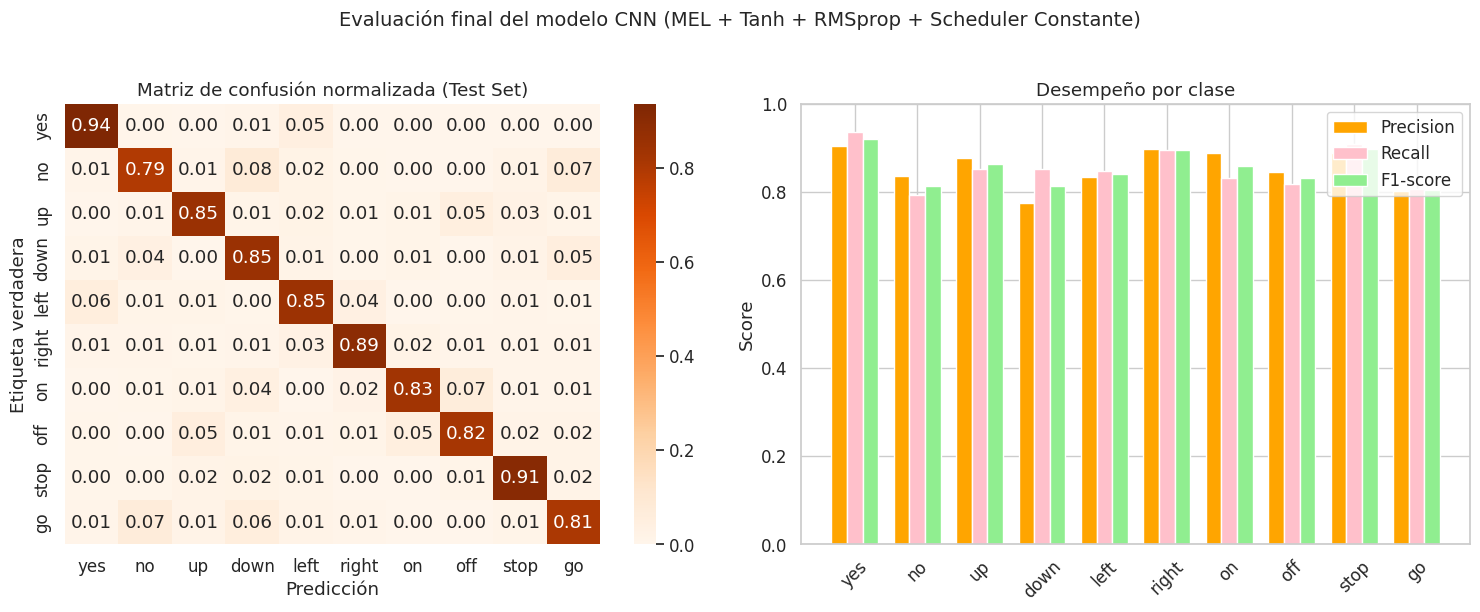

In [ ]:
# Generamos predicciones completas
y_true, y_pred = [], []
model.eval()
with torch.no_grad():
    for X, y in test_loader_mel_2d:
        X, y = X.to(DEVICE), y.to(DEVICE)
        outputs = model(X)
        _, preds = torch.max(outputs, 1)
        y_true.extend(y.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# Reportes y métricas
report = classification_report(y_true, y_pred, target_names=CLASSES, output_dict=True)
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Gráfico combinado
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Heatmap de matriz de confusión
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Oranges", ax=axes[0],
            xticklabels=CLASSES, yticklabels=CLASSES)
axes[0].set_xlabel("Predicción")
axes[0].set_ylabel("Etiqueta verdadera")
axes[0].set_title("Matriz de confusión normalizada (Test Set)")

# Métricas por clase
precision = [report[c]["precision"] for c in CLASSES]
recall    = [report[c]["recall"] for c in CLASSES]
f1        = [report[c]["f1-score"] for c in CLASSES]

x = np.arange(len(CLASSES))
width = 0.25

axes[1].bar(x - width, precision, width, color='orange', label='Precision')
axes[1].bar(x, recall, width, color='pink', label='Recall')
axes[1].bar(x + width, f1, width, color='lightgreen', label='F1-score')

axes[1].set_xticks(x)
axes[1].set_xticklabels(CLASSES, rotation=45)
axes[1].set_ylim(0, 1)
axes[1].set_ylabel('Score')
axes[1].set_title('Desempeño por clase')
axes[1].legend()

plt.suptitle("Evaluación final del modelo CNN (MEL + Tanh + RMSprop + Scheduler Constante)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

2. Con nuestros audios:

In [ ]:
# Subir audios
uploaded = files.upload()
list(uploaded.keys())

Saving down_lu.wav to down_lu.wav
Saving down_mili.wav to down_mili.wav
Saving down_petra.wav to down_petra.wav
Saving go_lu.wav to go_lu.wav
Saving go_mili.wav to go_mili.wav
Saving go_petra.wav to go_petra.wav
Saving left_lu.wav to left_lu.wav
Saving left_mili.wav to left_mili.wav
Saving left_petra.wav to left_petra.wav
Saving no_lu.wav to no_lu.wav
Saving no_mili.wav to no_mili.wav
Saving no_petra.wav to no_petra.wav
Saving off_lu.wav to off_lu.wav
Saving off_mili.wav to off_mili.wav
Saving off_petra.wav to off_petra.wav
Saving on_lu.wav to on_lu.wav
Saving on_mili.wav to on_mili.wav
Saving on_petra.wav to on_petra.wav
Saving right_lu.wav to right_lu.wav
Saving right_mili.wav to right_mili.wav
Saving right_petra.wav to right_petra.wav
Saving stop_lu.wav to stop_lu.wav
Saving stop_mili.wav to stop_mili.wav
Saving stop_petra.wav to stop_petra.wav
Saving up_lu.wav to up_lu.wav
Saving up_mili.wav to up_mili.wav
Saving up_petra.wav to up_petra.wav
Saving yes_lu.wav to yes_lu.wav
Saving y

['down_lu.wav',
 'down_mili.wav',
 'down_petra.wav',
 'go_lu.wav',
 'go_mili.wav',
 'go_petra.wav',
 'left_lu.wav',
 'left_mili.wav',
 'left_petra.wav',
 'no_lu.wav',
 'no_mili.wav',
 'no_petra.wav',
 'off_lu.wav',
 'off_mili.wav',
 'off_petra.wav',
 'on_lu.wav',
 'on_mili.wav',
 'on_petra.wav',
 'right_lu.wav',
 'right_mili.wav',
 'right_petra.wav',
 'stop_lu.wav',
 'stop_mili.wav',
 'stop_petra.wav',
 'up_lu.wav',
 'up_mili.wav',
 'up_petra.wav',
 'yes_lu.wav',
 'yes_mili.wav',
 'yes_petra.wav']

In [ ]:
def preprocess_audio_like_dataset(file_path):
    """
    Adapta los audios grabados al mismo formato que el dataset
    (mono, 16kHz, 1 seg, normalización y log-Mel)
    """
    wav, sr = torchaudio.load(file_path)

    if wav.shape[0] > 1:
        wav = wav.mean(dim=0, keepdim=True)

    if sr != NATIVE_SR:
        wav = torchaudio.transforms.Resample(sr, NATIVE_SR)(wav)
    target_len = NATIVE_SR

    if wav.shape[1] > target_len:
        wav = wav[:, :target_len]
    elif wav.shape[1] < target_len:
        wav = torch.nn.functional.pad(wav, (0, target_len - wav.shape[1]))

    mel = mel_tf_vis(wav)
    mel = torch.log(mel + 1e-6)
    mel = (mel - mel.mean()) / (mel.std() + 1e-6)
    mel = mel.unsqueeze(0)

    return wav, mel

Visualización y predicción:

/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/ffmpeg.py:88: UserWarning: torio.io._streaming_media_decoder.StreamingMediaDecoder has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/pytorch/audio/issues/3902 for more information. It will be r

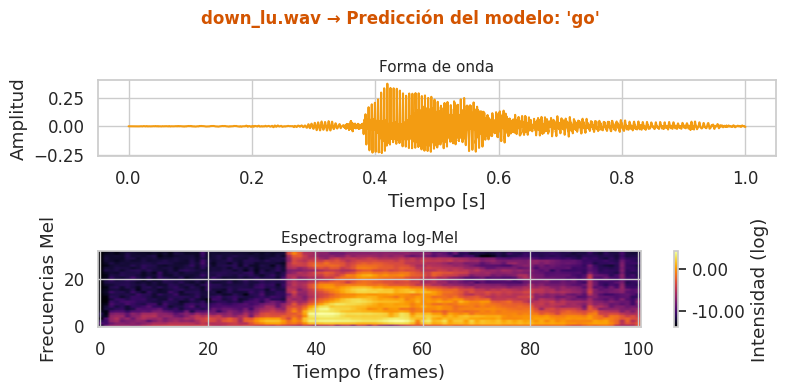

Reproduciendo down_lu.wav (predicción: go)


--------------------------------------------------------------------------------


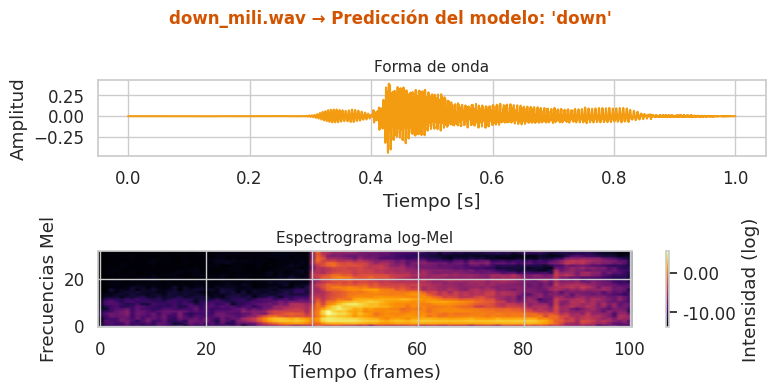

Reproduciendo down_mili.wav (predicción: down)


--------------------------------------------------------------------------------


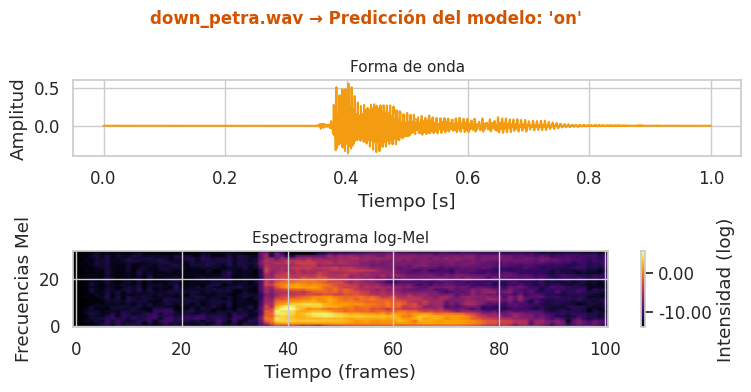

Reproduciendo down_petra.wav (predicción: on)


--------------------------------------------------------------------------------


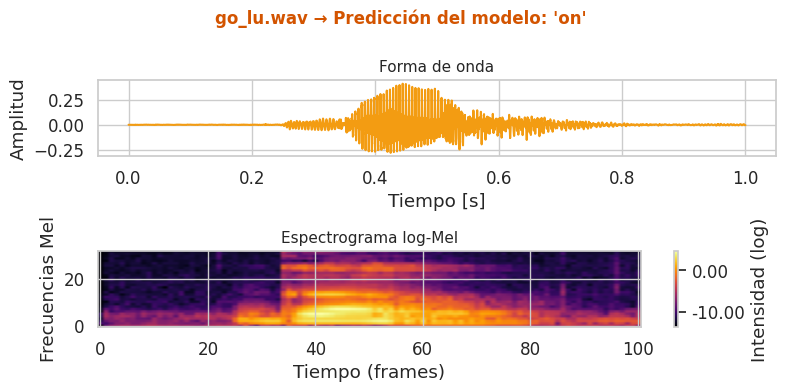

Reproduciendo go_lu.wav (predicción: on)


--------------------------------------------------------------------------------


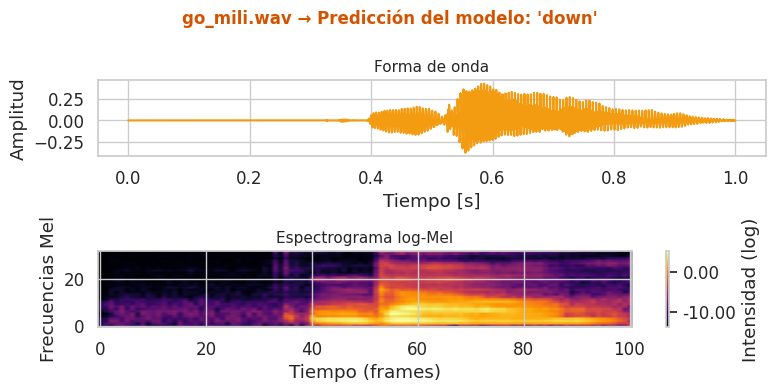

Reproduciendo go_mili.wav (predicción: down)


--------------------------------------------------------------------------------


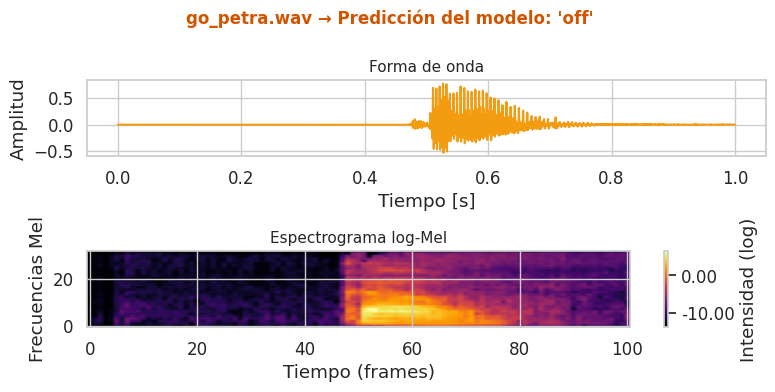

Reproduciendo go_petra.wav (predicción: off)


--------------------------------------------------------------------------------


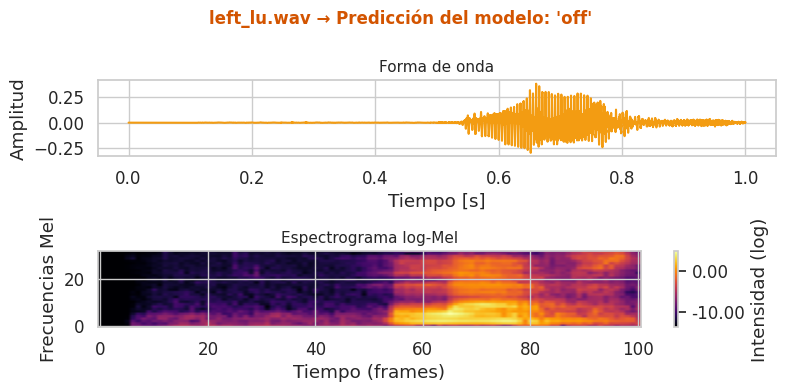

Reproduciendo left_lu.wav (predicción: off)


--------------------------------------------------------------------------------


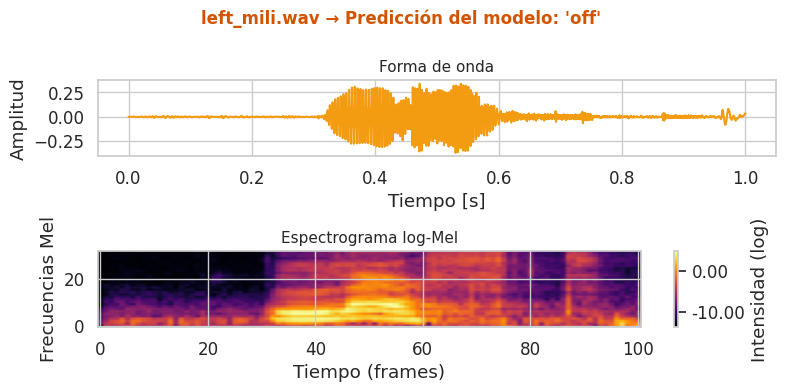

Reproduciendo left_mili.wav (predicción: off)


--------------------------------------------------------------------------------


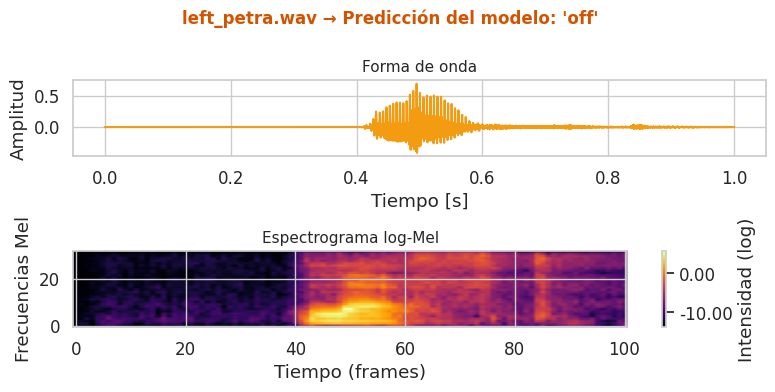

Reproduciendo left_petra.wav (predicción: off)


--------------------------------------------------------------------------------


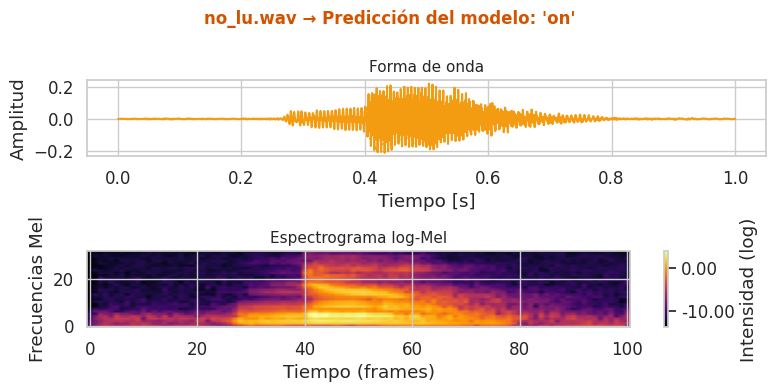

Reproduciendo no_lu.wav (predicción: on)


--------------------------------------------------------------------------------


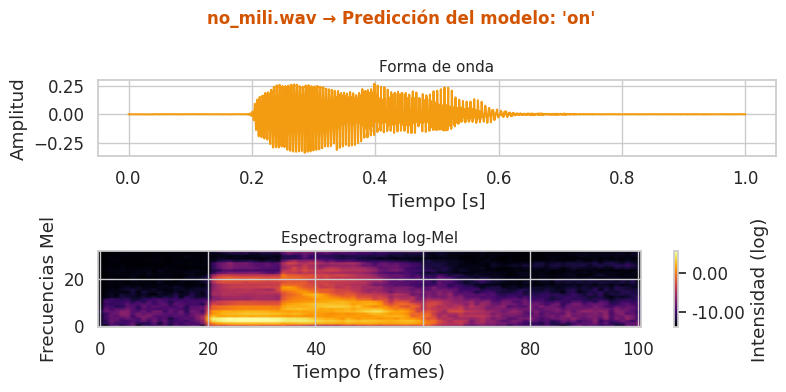

Reproduciendo no_mili.wav (predicción: on)


--------------------------------------------------------------------------------


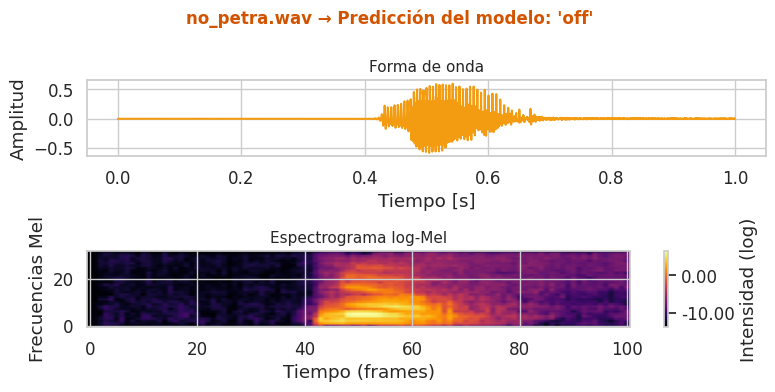

Reproduciendo no_petra.wav (predicción: off)


--------------------------------------------------------------------------------


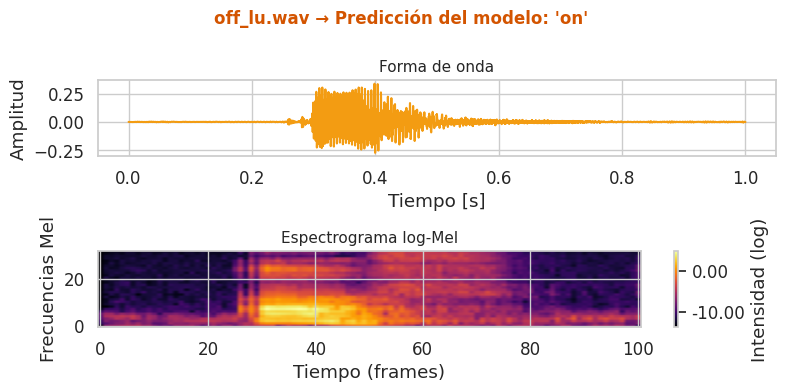

Reproduciendo off_lu.wav (predicción: on)


--------------------------------------------------------------------------------


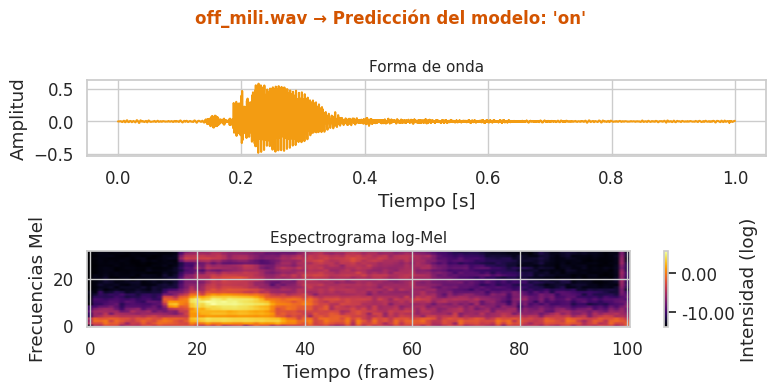

Reproduciendo off_mili.wav (predicción: on)


--------------------------------------------------------------------------------


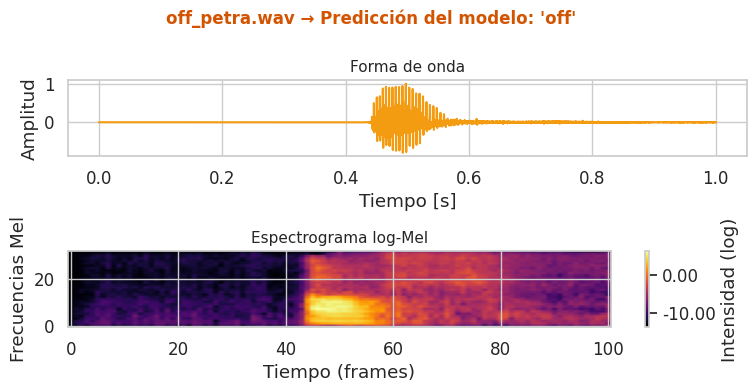

Reproduciendo off_petra.wav (predicción: off)


--------------------------------------------------------------------------------


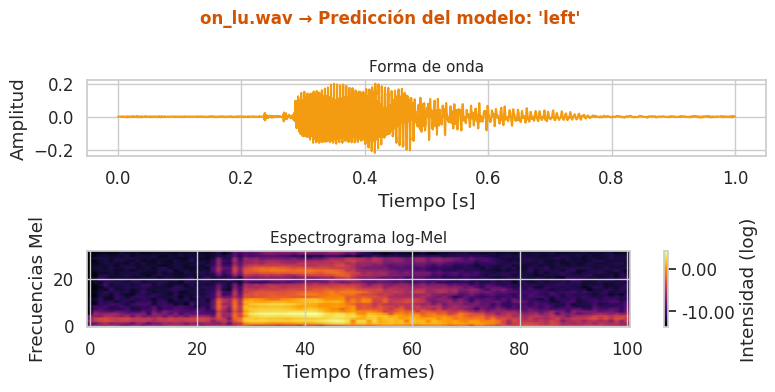

Reproduciendo on_lu.wav (predicción: left)


--------------------------------------------------------------------------------


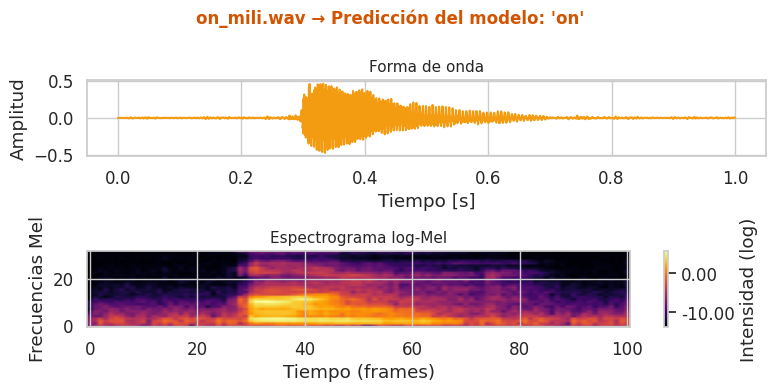

Reproduciendo on_mili.wav (predicción: on)


--------------------------------------------------------------------------------


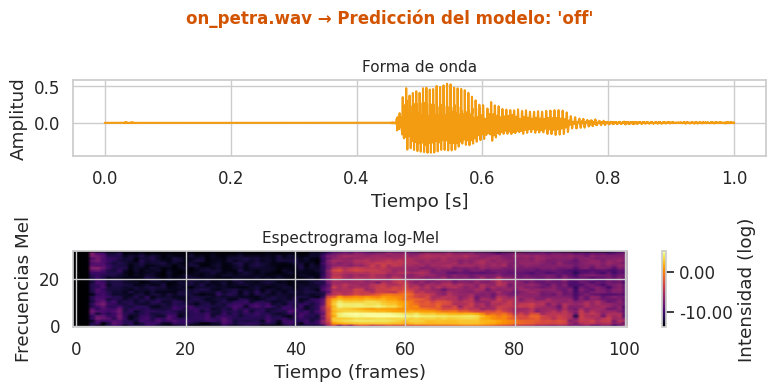

Reproduciendo on_petra.wav (predicción: off)


--------------------------------------------------------------------------------


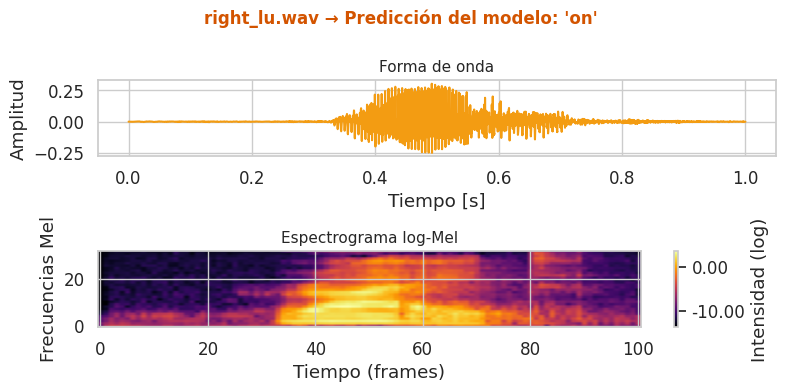

Reproduciendo right_lu.wav (predicción: on)


--------------------------------------------------------------------------------


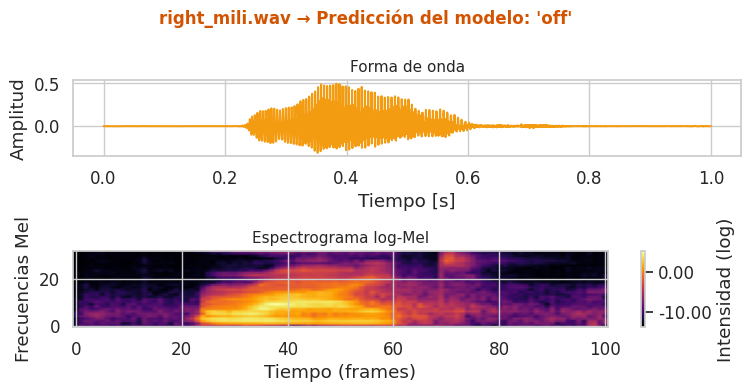

Reproduciendo right_mili.wav (predicción: off)


--------------------------------------------------------------------------------


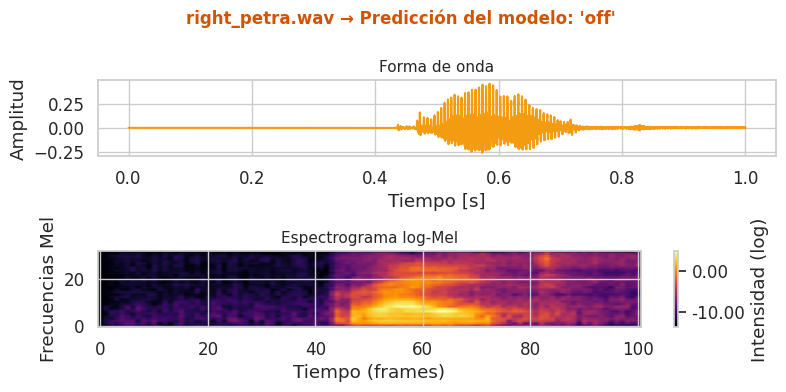

Reproduciendo right_petra.wav (predicción: off)


--------------------------------------------------------------------------------


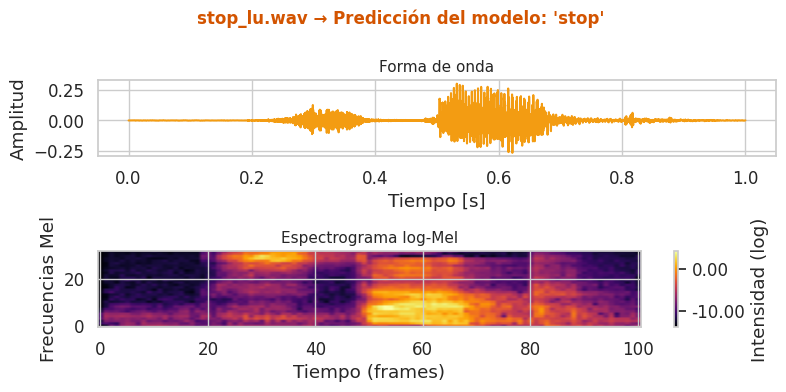

Reproduciendo stop_lu.wav (predicción: stop)


--------------------------------------------------------------------------------


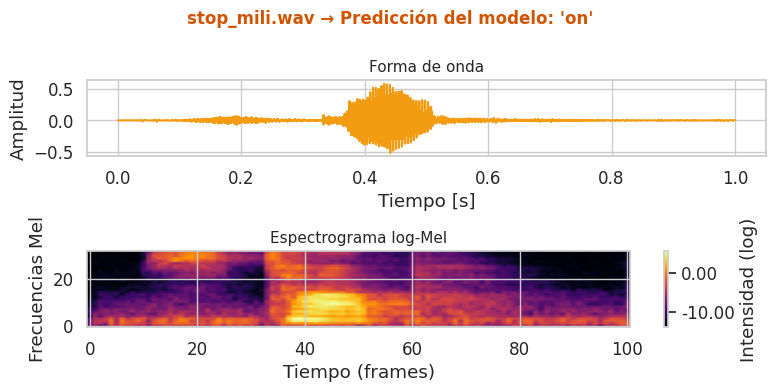

Reproduciendo stop_mili.wav (predicción: on)


--------------------------------------------------------------------------------


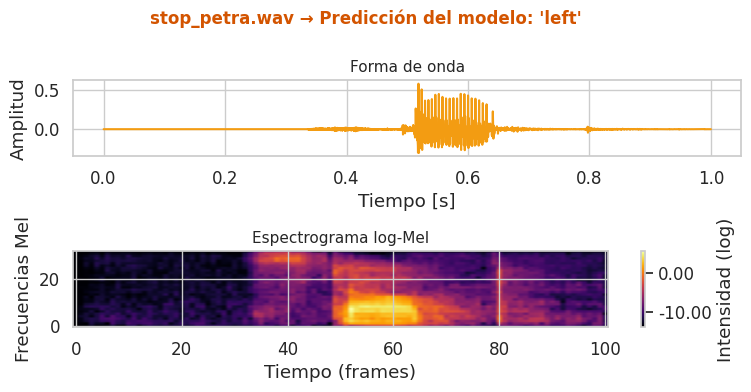

Reproduciendo stop_petra.wav (predicción: left)


--------------------------------------------------------------------------------


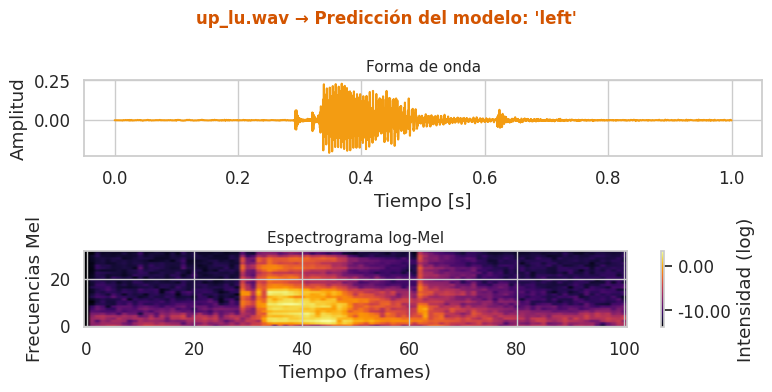

Reproduciendo up_lu.wav (predicción: left)


--------------------------------------------------------------------------------


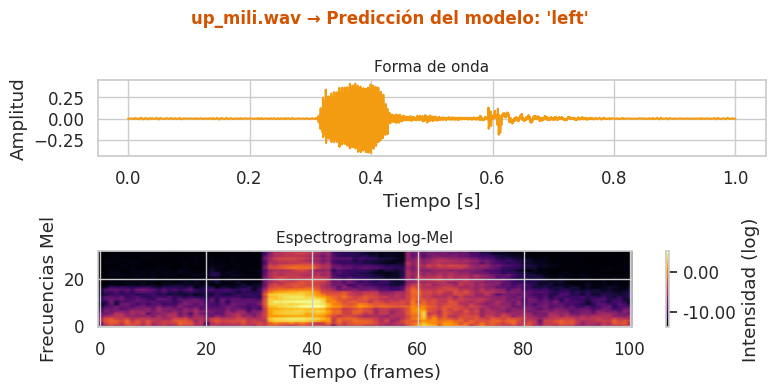

Reproduciendo up_mili.wav (predicción: left)


--------------------------------------------------------------------------------


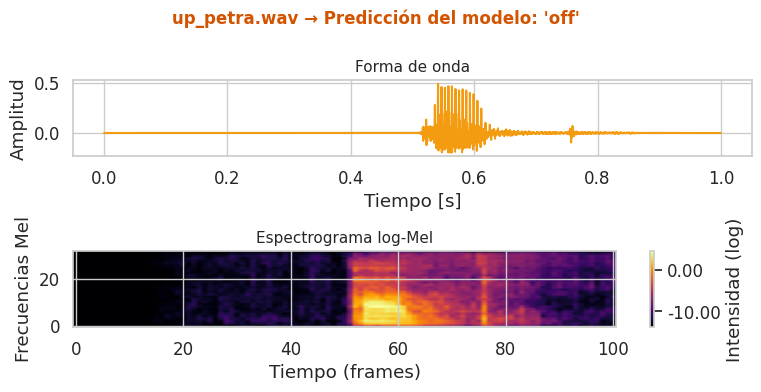

Reproduciendo up_petra.wav (predicción: off)


--------------------------------------------------------------------------------


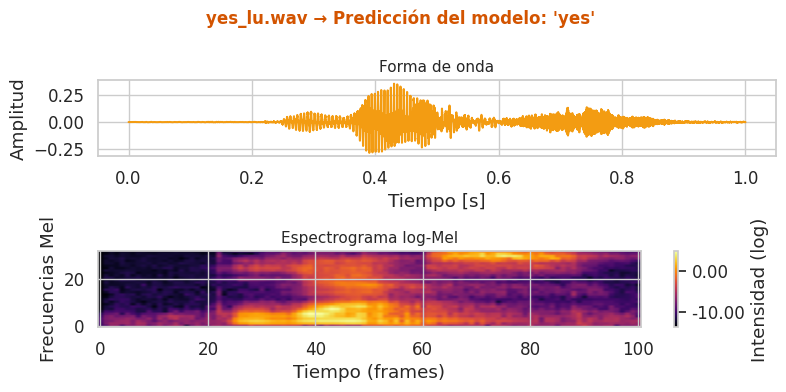

Reproduciendo yes_lu.wav (predicción: yes)


--------------------------------------------------------------------------------


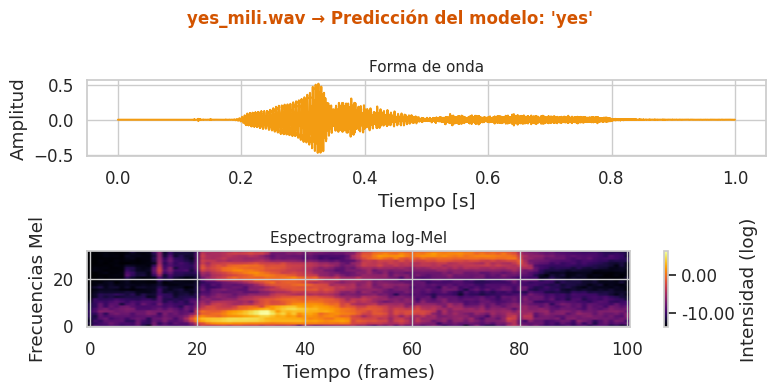

Reproduciendo yes_mili.wav (predicción: yes)


--------------------------------------------------------------------------------


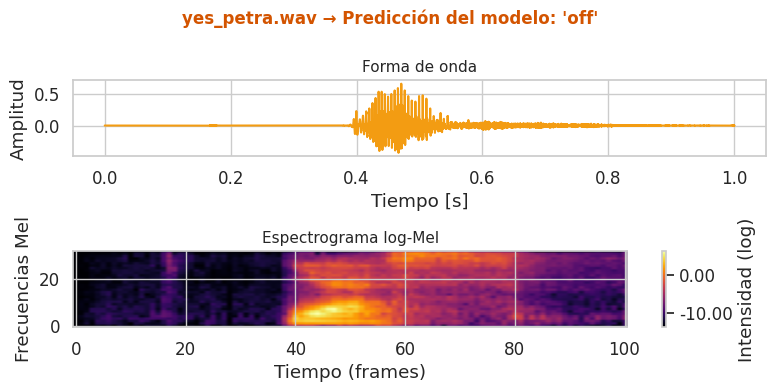

Reproduciendo yes_petra.wav (predicción: off)


--------------------------------------------------------------------------------


In [ ]:
for file in uploaded.keys():
    wav, mel_spec = preprocess_audio_like_dataset(file)
    mel_spec = mel_spec.to(DEVICE)

    with torch.no_grad():
        output = model(mel_spec)
        _, pred = torch.max(output, 1)
        pred_label = CLASSES[pred.item()]

    # Forma de onda
    x = wav.squeeze().numpy()
    t = np.arange(len(x)) / NATIVE_SR

    fig, axes = plt.subplots(2, 1, figsize=(8, 4))
    fig.suptitle(f"{file} → Predicción del modelo: '{pred_label}'", fontsize=12, fontweight="bold", color="#d35400")

    # Waveform
    axes[0].plot(t, x, color="#f39c12")
    axes[0].set_title("Forma de onda", fontsize=11)
    axes[0].set_xlabel("Tiempo [s]")
    axes[0].set_ylabel("Amplitud")

    # Espectograma log-Mel
    M = mel_tf_vis(wav)
    LM = torch.log(M + 1e-6).squeeze(0).numpy()
    im = axes[1].imshow(LM, aspect="auto", origin="lower", cmap="inferno")
    axes[1].set_title("Espectrograma log-Mel", fontsize=11)
    axes[1].set_xlabel("Tiempo (frames)")
    axes[1].set_ylabel("Frecuencias Mel")
    fig.colorbar(im, ax=axes[1], format="%.2f", label="Intensidad (log)")

    plt.tight_layout()
    plt.show()

    # Reproducir audio
    print(f"Reproduciendo {file} (predicción: {pred_label})")
    display(Audio(x, rate=NATIVE_SR))
    print("-" * 80)

Evaluación cuantitativa:

In [ ]:
y_true, y_pred = [], []

model.eval()
with torch.no_grad():
    for file in uploaded.keys():
        wav, mel_spec = preprocess_audio_like_dataset(file)
        mel_spec = mel_spec.to(DEVICE)
        output = model(mel_spec)
        _, pred = torch.max(output, 1)
        pred_label = CLASSES[pred.item()]
        true_label = file.split("_")[0].lower()  # el nombre del archivo marca la clase real
        y_true.append(true_label)
        y_pred.append(pred_label)

# Reporte y matriz cruda
print("Reporte de Clasificación (audios grabados):")
print(classification_report(y_true, y_pred, target_names=CLASSES, zero_division=0))

cm = confusion_matrix(y_true, y_pred, labels=CLASSES)
print("\nMatriz de confusión:\n", cm)

/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/ffmpeg.py:88: UserWarning: torio.io._streaming_media_decoder.StreamingMediaDecoder has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/pytorch/audio/issues/3902 for more information. It will be r

Reporte de Clasificación (audios grabados):
              precision    recall  f1-score   support

         yes       0.50      0.33      0.40         3
          no       0.00      0.00      0.00         3
          up       0.00      0.00      0.00         3
        down       0.00      0.00      0.00         3
        left       0.09      0.33      0.14         3
       right       0.11      0.33      0.17         3
          on       0.00      0.00      0.00         3
         off       1.00      0.33      0.50         3
        stop       0.00      0.00      0.00         3
          go       1.00      0.67      0.80         3

    accuracy                           0.20        30
   macro avg       0.27      0.20      0.20        30
weighted avg       0.27      0.20      0.20        30


Matriz de confusión:
 [[2 0 0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 2 1 0 0]
 [0 0 0 0 2 0 0 1 0 0]
 [0 0 0 1 0 0 1 0 0 1]
 [0 0 0 0 0 0 0 3 0 0]
 [0 0 0 0 0 0 1 2 0 0]
 [0 0 0 0 1 0 1 1 0 0]
 [0 0 0 0 0 0

Evaluación:

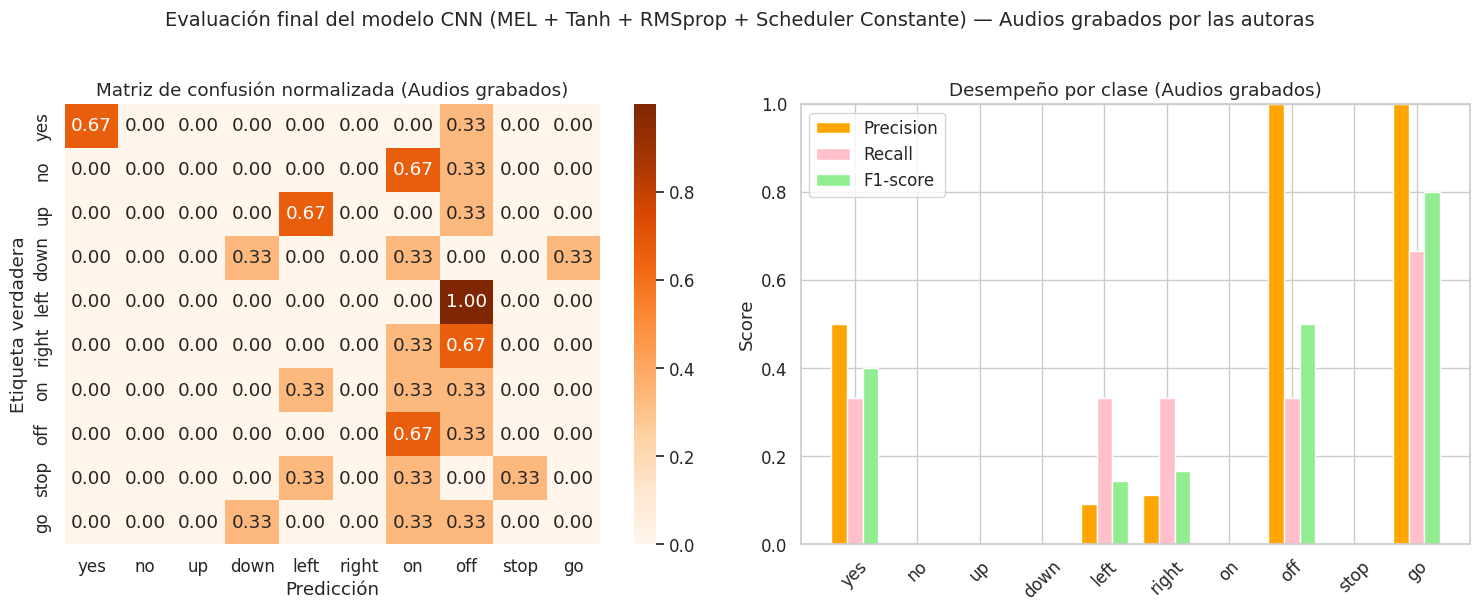

In [ ]:
report = classification_report(y_true, y_pred, target_names=CLASSES, output_dict=True, zero_division=0)
cm_norm = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-9)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Heatmap de la matriz de confusión
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Oranges", ax=axes[0],
            xticklabels=CLASSES, yticklabels=CLASSES)
axes[0].set_xlabel("Predicción")
axes[0].set_ylabel("Etiqueta verdadera")
axes[0].set_title("Matriz de confusión normalizada (Audios grabados)")

# Barras de métricas por clase
precision = [report[c]["precision"] for c in CLASSES]
recall    = [report[c]["recall"] for c in CLASSES]
f1        = [report[c]["f1-score"] for c in CLASSES]

x = np.arange(len(CLASSES))
width = 0.25

axes[1].bar(x - width, precision, width, color='orange', label='Precision')
axes[1].bar(x, recall, width, color='pink', label='Recall')
axes[1].bar(x + width, f1, width, color='lightgreen', label='F1-score')

axes[1].set_xticks(x)
axes[1].set_xticklabels(CLASSES, rotation=45)
axes[1].set_ylim(0, 1)
axes[1].set_ylabel('Score')
axes[1].set_title('Desempeño por clase (Audios grabados)')
axes[1].legend()

plt.suptitle("Evaluación final del modelo CNN (MEL + Tanh + RMSprop + Scheduler Constante) — Audios grabados por las autoras",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()